# Liver regeneration graph pipeline
## Block 1 — Setup, configuration, and data loading

This block defines:

- required imports,
- dataset paths and label IDs,
- helper functions for reading and cropping 3D volumes,
- a main loader that reads all channels consistently.

The goal is to prepare a clean and reproducible entry point for the full pipeline.

In [1]:
# =========================
# Block 0 — System-aware setup and global configuration
# =========================
import os

# Limit internal numerical-library threads.
# Later, if we parallelize across cells, each worker should not spawn too many extra threads.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from pathlib import Path
import gc
import numpy as np
import tifffile
import pandas as pd
import napari

from skimage.segmentation import expand_labels
import matplotlib.pyplot as plt


from scipy import ndimage as ndi
from skimage.measure import marching_cubes
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
import trimesh
from numpy.linalg import norm, eigh
from itertools import combinations
import networkx as nx
from scipy.spatial import cKDTree

In [2]:
# -------------------------
# Dataset path
DATA_DIR = Path("/home/ws25091/Alejandro_liver_graph/data/Muestra_elife")
FILE_BC = "BC.tif"
FILE_CELLS = "Cells.tif"
FILE_NUCLEI = "Nuclei.tif"
FILE_SINUSOIDS = "Sinusoids.tif"
FILE_VCVP = "CV-PV.tif"

FILES = {
    "bc": FILE_BC,
    "cells": FILE_CELLS,
    "nuclei": FILE_NUCLEI,
    "sinusoids": FILE_SINUSOIDS,
    "vcvp": FILE_VCVP,
}

# -------------------------
# Raw labels in the VC-VP file
# -------------------------
RAW_ID_CV = 100   # Central vein in raw VC-VP image
RAW_ID_PV = 200   # Portal vein in raw VC-VP image

# -------------------------
# Labels inside master_labels
# -------------------------
ID_CV = 65531
ID_PV = 65532
ID_BORDER = 65533
ID_BILE = 65534
ID_SINU = 65535

# -------------------------
# Run mode and output
# -------------------------
RUN_MODE = "full"
DO_NAPARI = False
DO_DEBUG_PLOTS = False

OUTPUT_DIR = Path("~/Alejandro_liver_graph/outputs/full_20220418_3_01").expanduser()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Resource configuration
# -------------------------
N_JOBS = 16

# Expansion distance for hepatocyte labels
EXPANSION_DIST = 20

In [3]:
# =========================
# Block 1 — TIFF metadata and memory-safe helper functions
# =========================

def get_tiff_metadata(path):
    """
    Read TIFF metadata without loading the full image into RAM.

    Parameters
    ----------
    path : str or Path
        Path to a TIFF file.

    Returns
    -------
    dict
        Dictionary with path, shape, dtype, file size, and estimated RAM usage.
    """
    path = Path(path)

    with tifffile.TiffFile(path) as tif:
        series = tif.series[0]
        shape = series.shape
        dtype = series.dtype

    file_size_gib = path.stat().st_size / 1024**3
    ram_gib = np.prod(shape) * np.dtype(dtype).itemsize / 1024**3

    return {
        "path": path,
        "shape": shape,
        "dtype": dtype,
        "file_size_gib": file_size_gib,
        "estimated_ram_gib": ram_gib,
    }


def print_dataset_metadata(data_dir, files):
    """
    Print metadata for all required TIFF files.

    This checks that the files exist and reports their shape, dtype,
    file size on disk, and estimated RAM if fully loaded.
    """
    rows = []

    for key, fname in files.items():
        path = Path(data_dir) / fname

        if not path.exists():
            rows.append({
                "name": key,
                "file": fname,
                "exists": False,
                "shape": None,
                "dtype": None,
                "file_size_GiB": None,
                "RAM_if_loaded_GiB": None,
            })
            continue

        meta = get_tiff_metadata(path)

        rows.append({
            "name": key,
            "file": fname,
            "exists": True,
            "shape": meta["shape"],
            "dtype": str(meta["dtype"]),
            "file_size_GiB": meta["file_size_gib"],
            "RAM_if_loaded_GiB": meta["estimated_ram_gib"],
        })

    df = pd.DataFrame(rows)
    display(df)
    return df


def open_memmap(path):
    """
    Open a TIFF as a numpy memmap.

    This allows us to access parts of the image without loading
    the full volume into RAM.
    """
    return tifffile.memmap(Path(path))


def sanitize_crop_bounds(bounds, shape):
    """
    Make sure crop bounds are inside the volume.

    Parameters
    ----------
    bounds : tuple
        Crop bounds as (z0, z1, y0, y1, x0, x1).

    shape : tuple
        Full volume shape as (z, y, x).

    Returns
    -------
    tuple
        Validated crop bounds as (z0, z1, y0, y1, x0, x1).
    """
    z0, z1, y0, y1, x0, x1 = bounds
    max_z, max_y, max_x = shape

    z0 = max(0, min(int(z0), max_z))
    z1 = max(0, min(int(z1), max_z))

    y0 = max(0, min(int(y0), max_y))
    y1 = max(0, min(int(y1), max_y))

    x0 = max(0, min(int(x0), max_x))
    x1 = max(0, min(int(x1), max_x))

    if z1 <= z0:
        raise ValueError(f"Invalid z bounds: {z0}:{z1}")
    if y1 <= y0:
        raise ValueError(f"Invalid y bounds: {y0}:{y1}")
    if x1 <= x0:
        raise ValueError(f"Invalid x bounds: {x0}:{x1}")

    return z0, z1, y0, y1, x0, x1


def describe_crop_bounds(bounds):
    """
    Print crop bounds in a readable way.
    """
    z0, z1, y0, y1, x0, x1 = bounds

    nz = z1 - z0
    ny = y1 - y0
    nx = x1 - x0

    total_voxels = nz * ny * nx
    ram_uint16_gib = total_voxels * np.dtype(np.uint16).itemsize / 1024**3

    print("Crop bounds:")
    print(f"  Z: {z0}:{z1}  size = {nz}")
    print(f"  Y: {y0}:{y1}  size = {ny}")
    print(f"  X: {x0}:{x1}  size = {nx}")
    print(f"  Total voxels: {total_voxels:,}")
    print(f"  RAM per uint16 channel: {ram_uint16_gib:.3f} GiB")


def read_crop_zyx(path, bounds, output_dtype=np.uint16):
    """
    Read a z-y-x crop from a TIFF using memmap.

    Parameters
    ----------
    path : str or Path
        TIFF path.

    bounds : tuple
        Crop bounds as (z0, z1, y0, y1, x0, x1).

    output_dtype : dtype or None
        Desired dtype after reading the crop.
        If None, the original dtype is preserved.

    Returns
    -------
    np.ndarray
        Cropped volume as a normal in-memory NumPy array.
    """
    path = Path(path)

    arr = open_memmap(path)

    z0, z1, y0, y1, x0, x1 = sanitize_crop_bounds(
        bounds=bounds,
        shape=arr.shape,
    )

    # This reads only the selected crop into RAM.
    crop = np.asarray(arr[z0:z1, y0:y1, x0:x1])

    # Your TIFFs are big-endian uint16 (>u2).
    # This converts only the crop, not the full image, to native uint16.
    if output_dtype is not None:
        crop = crop.astype(output_dtype, copy=False)

    return crop


# -------------------------
# Run metadata check
# -------------------------
metadata_df = print_dataset_metadata(DATA_DIR, FILES)

# Use the Cells file as reference for the common volume shape.
REF_SHAPE = get_tiff_metadata(DATA_DIR / FILE_CELLS)["shape"]

print("\nReference shape from Cells file:")
print(REF_SHAPE)

,name,file,exists,shape,dtype,file_size_GiB,RAM_if_loaded_GiB
0,bc,BC.tif,True,"(307, 1488, 1418)",uint16,1.206641,1.206556
1,cells,Cells.tif,True,"(307, 1488, 1418)",uint16,1.206641,1.206556
2,nuclei,Nuclei.tif,True,"(307, 1488, 1418)",uint16,1.206641,1.206556
3,sinusoids,Sinusoids.tif,True,"(307, 1488, 1418)",uint16,1.206641,1.206556
4,vcvp,CV-PV.tif,True,"(307, 1488, 1418)",uint16,1.206641,1.206556



Reference shape from Cells file:
(307, 1488, 1418)


In [4]:
# =========================
# Block 2 — Define full-volume bounds
# =========================

max_z, max_y, max_x = REF_SHAPE

print("Full image shape:")
print(" Z:", max_z)
print(" Y:", max_y)
print(" X:", max_x)

if RUN_MODE == "full":
    ACTIVE_CROP_MODE = "full"
    CROP_BOUNDS = (
        0, max_z,
        0, max_y,
        0, max_x,
    )

elif RUN_MODE == "manual":
    ACTIVE_CROP_MODE = "manual"
    CROP_BOUNDS = (
        100, 340,
        600, 1050,
        0, max_x,
    )
    CROP_BOUNDS = sanitize_crop_bounds(CROP_BOUNDS, REF_SHAPE)

else:
    raise ValueError("RUN_MODE must be 'full' or 'manual'.")

print("\nActive crop mode:", ACTIVE_CROP_MODE)
describe_crop_bounds(CROP_BOUNDS)

Full image shape:
 Z: 307
 Y: 1488
 X: 1418

Active crop mode: full
Crop bounds:
  Z: 0:307  size = 307
  Y: 0:1488  size = 1488
  X: 0:1418  size = 1418
  Total voxels: 647,765,088
  RAM per uint16 channel: 1.207 GiB


In [5]:
# =========================
# Block 3 — Load the selected crop and build corrected master_labels
# =========================

# -------------------------
# Load crop volumes
# -------------------------
cells_crop = read_crop_zyx(DATA_DIR / FILE_CELLS, CROP_BOUNDS, output_dtype=np.uint16)
bc_crop = read_crop_zyx(DATA_DIR / FILE_BC, CROP_BOUNDS, output_dtype=np.uint16)
sinu_crop = read_crop_zyx(DATA_DIR / FILE_SINUSOIDS, CROP_BOUNDS, output_dtype=np.uint16)
nuclei_crop = read_crop_zyx(DATA_DIR / FILE_NUCLEI, CROP_BOUNDS, output_dtype=np.uint16)
vcvp_crop = read_crop_zyx(DATA_DIR / FILE_VCVP, CROP_BOUNDS, output_dtype=np.uint16)

print("Crop loaded successfully.")
print("Crop shape:", cells_crop.shape)

# -------------------------
# Expand hepatocyte labels
# -------------------------
print("\nExpanding hepatocyte labels...")
expanded_cells = expand_labels(
    cells_crop,
    distance=EXPANSION_DIST
).astype(np.uint32, copy=False)

# -------------------------
# Build master_labels
# -------------------------
print("Building master_labels...")

master_labels = expanded_cells.copy()

# Binary masks for structures
is_bile = bc_crop > 0
is_sinu = sinu_crop > 0
is_cv = vcvp_crop == RAW_ID_CV
is_pv = vcvp_crop == RAW_ID_PV

# Insert structures into master_labels
# Order matters. Vessels are written last so they remain explicit landmarks.
master_labels[is_sinu] = ID_SINU
master_labels[is_bile] = ID_BILE
master_labels[is_cv] = ID_CV
master_labels[is_pv] = ID_PV

# -------------------------
# Basic summary
# -------------------------
cell_ids = np.unique(expanded_cells)
cell_ids = cell_ids[cell_ids > 0]

print("\n==============================")
print("Crop summary after loading")
print("==============================")
print("Expanded cells shape:", expanded_cells.shape)
print("Expanded cells dtype:", expanded_cells.dtype)
print("Number of hepatocyte IDs:", len(cell_ids))

print("\nStructure voxel counts:")
print("  Bile voxels:", int(np.count_nonzero(is_bile)))
print("  Sinusoid voxels:", int(np.count_nonzero(is_sinu)))
print("  CV voxels:", int(np.count_nonzero(is_cv)))
print("  PV voxels:", int(np.count_nonzero(is_pv)))

print("\nLabels used in master_labels:")
print("  ID_CV:", ID_CV)
print("  ID_PV:", ID_PV)
print("  ID_BILE:", ID_BILE)
print("  ID_SINU:", ID_SINU)

# -------------------------
# Pack data for later blocks
# -------------------------
data = {
    "cells_raw": cells_crop,
    "cells_expanded": expanded_cells,
    "bc_raw": bc_crop,
    "sinusoids_raw": sinu_crop,
    "nuclei_raw": nuclei_crop,
    "vcvp_raw": vcvp_crop,
    "master_labels": master_labels,
    "crop_bounds": CROP_BOUNDS,
    "crop_mode": ACTIVE_CROP_MODE,
}


hepa_raw = data["cells_raw"]
hepa_img = data["cells_expanded"]
bile_img = data["bc_raw"]
sinu_img = data["sinusoids_raw"]
nuclei_img = data["nuclei_raw"]
vcvp_img = data["vcvp_raw"]

print("\nData dictionary created successfully.")
print("Variables prepared:")
print("  hepa_raw, hepa_img, bile_img, sinu_img, nuclei_img, vcvp_img, master_labels")

Crop loaded successfully.
Crop shape: (307, 1488, 1418)

Expanding hepatocyte labels...
Building master_labels...

Crop summary after loading
Expanded cells shape: (307, 1488, 1418)
Expanded cells dtype: uint32
Number of hepatocyte IDs: 1896

Structure voxel counts:
  Bile voxels: 22404192
  Sinusoid voxels: 86089246
  CV voxels: 31753709
  PV voxels: 33799008

Labels used in master_labels:
  ID_CV: 65531
  ID_PV: 65532
  ID_BILE: 65534
  ID_SINU: 65535

Data dictionary created successfully.
Variables prepared:
  hepa_raw, hepa_img, bile_img, sinu_img, nuclei_img, vcvp_img, master_labels


## Block 2 — Hepatocyte mesh generation

In this block we generate one surface mesh per hepatocyte from the cropped label volume.

Key decisions:

- only hepatocytes are meshed,
- the label volume is padded before `marching_cubes` to avoid boundary issues,
- each mesh is stored in a dictionary indexed by hepatocyte ID,
- mesh orientation is corrected when necessary.

These meshes will later be used for face-wise topological mapping and physical analysis.

In [6]:
# Padding around each local cell crop.
# This helps marching_cubes close the surface around each cell.
CELL_MESH_PAD = 2

print("Preparing hepatocyte mesh generation utilities...")
print("N_JOBS:", N_JOBS)
print("CELL_MESH_PAD:", CELL_MESH_PAD)


def expand_local_slices(local_slices, pad, volume_shape):
    """
    Expand a local bounding box by a small padding while staying inside the volume.

    Parameters
    ----------
    local_slices : tuple of slices
        Bounding box returned by scipy.ndimage.find_objects.

    pad : int
        Number of voxels added around the bounding box.

    volume_shape : tuple
        Shape of the full label volume as (z, y, x).

    Returns
    -------
    tuple of slices
        Expanded bounding box.
    """
    expanded = []

    for slc, max_size in zip(local_slices, volume_shape):
        start = max(0, slc.start - pad)
        stop = min(max_size, slc.stop + pad)
        expanded.append(slice(start, stop))

    return tuple(expanded)


def generate_single_cell_mesh(label_volume, cell_id, label_slices, pad=2):
    """
    Generate a mesh for one hepatocyte using only its local bounding box.

    Parameters
    ----------
    label_volume : np.ndarray
        3D label image containing hepatocyte IDs.

    cell_id : int
        Label ID of the hepatocyte to mesh.

    label_slices : list
        Output of scipy.ndimage.find_objects(label_volume).

    pad : int
        Extra padding around the cell bounding box.

    Returns
    -------
    tuple or None
        (cell_id, mesh) if successful, otherwise None.
    """
    cell_id = int(cell_id)

    # scipy.ndimage.find_objects stores label k at index k-1.
    if cell_id <= 0 or cell_id > len(label_slices):
        return None

    local_slices = label_slices[cell_id - 1]

    if local_slices is None:
        return None

    # Expand the bounding box slightly.
    local_slices = expand_local_slices(
        local_slices=local_slices,
        pad=pad,
        volume_shape=label_volume.shape,
    )

    z_slice, y_slice, x_slice = local_slices

    # Local crop containing only this cell and a small surrounding region.
    local_labels = label_volume[z_slice, y_slice, x_slice]

    # Binary mask for this specific cell.
    local_mask = local_labels == cell_id

    if not np.any(local_mask):
        return None

    # Pad the local binary mask with background.
    # This helps marching_cubes generate a closed surface.
    local_mask_padded = np.pad(
        local_mask,
        pad_width=1,
        mode="constant",
        constant_values=False,
    )

    try:
        verts, faces, normals, values = marching_cubes(
            local_mask_padded.astype(np.uint8),
            level=0.5,
        )
    except Exception as e:
        print(f"Mesh failed for cell {cell_id}: {e}")
        return None

    # Remove the artificial padding offset.
    verts -= 1.0

    # Move vertices from local crop coordinates back to global crop coordinates.
    offset = np.array(
        [z_slice.start, y_slice.start, x_slice.start],
        dtype=np.float32,
    )

    verts = verts + offset

    mesh = trimesh.Trimesh(
        vertices=verts,
        faces=faces,
        process=False,
    )

    # Correct orientation if needed.
    try:
        if mesh.volume < 0:
            mesh.invert()
    except Exception:
        pass

    return cell_id, mesh


# -------------------------
# Build list of hepatocyte IDs and bounding boxes
# -------------------------
cell_ids_for_mesh = np.unique(hepa_img)
cell_ids_for_mesh = cell_ids_for_mesh[cell_ids_for_mesh > 0]

print("\nNumber of hepatocyte IDs available for meshing:", len(cell_ids_for_mesh))

cell_label_slices = ndi.find_objects(hepa_img)

Preparing hepatocyte mesh generation utilities...
N_JOBS: 16
CELL_MESH_PAD: 2

Number of hepatocyte IDs available for meshing: 1896


In [7]:
cell_meshes = {}
failed_cell_ids = []

with ThreadPoolExecutor(max_workers=N_JOBS) as executor:
    futures = {}

    for cid in cell_ids_for_mesh:
        future = executor.submit(
            generate_single_cell_mesh,
            label_volume=hepa_img,
            cell_id=cid,
            label_slices=cell_label_slices,
            pad=CELL_MESH_PAD,
        )
        futures[future] = cid

    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        desc="Meshing hepatocytes"
    ):
        cid = futures[future]

        try:
            result = future.result()
        except Exception as e:
            print(f"Cell {cid}: mesh generation failed with error: {e}")
            failed_cell_ids.append(cid)
            continue

        if result is None:
            failed_cell_ids.append(cid)
            continue

        cid_out, mesh = result
        cell_meshes[cid_out] = mesh

print("\n==============================")
print("Hepatocyte mesh generation summary")
print("==============================")
print("Requested cells:", len(cell_ids_for_mesh))
print("Generated meshes:", len(cell_meshes))
print("Failed meshes:", len(failed_cell_ids))

if len(failed_cell_ids) > 0:
    print("Failed cell IDs:")
    print(failed_cell_ids[:50])
    if len(failed_cell_ids) > 50:
        print("...")

# Basic mesh statistics and geometric centers
mesh_summary_rows = []

for cid, mesh in cell_meshes.items():
    centroid = mesh.centroid
    center_mass = mesh.center_mass

    mesh_summary_rows.append({
        "cell_id": cid,

        "n_vertices": len(mesh.vertices),
        "n_faces": len(mesh.faces),

        "mesh_volume": mesh.volume,
        "mesh_area": mesh.area,

        # Coordinates are in global crop coordinates: (z, y, x)
        "mesh_centroid_zyx": centroid.tolist(),
        "mesh_center_mass_zyx": center_mass.tolist(),

        # Also store them as separate columns for easier plotting/filtering later
        "mesh_centroid_z": centroid[0],
        "mesh_centroid_y": centroid[1],
        "mesh_centroid_x": centroid[2],

        "mesh_center_mass_z": center_mass[0],
        "mesh_center_mass_y": center_mass[1],
        "mesh_center_mass_x": center_mass[2],
    })

cell_mesh_summary = pd.DataFrame(mesh_summary_rows)

#print("\nMesh statistics:")
#display(cell_mesh_summary.describe())

Meshing hepatocytes:   0%|          | 0/1896 [00:00<?, ?it/s]


Hepatocyte mesh generation summary
Requested cells: 1896
Generated meshes: 1896
Failed meshes: 0


In [8]:
# =========================
# Block 9 — Nucleus instance meshing and basic nucleus properties
# =========================

#NUCLEUS_TYPE_LABELS = {
#    100: "normal_hepatocyte_nucleus",
#    200: "metaphase",
#    300: "anaphase_telophase",
#    400: "cytokinesis",
#}


NUCLEUS_TYPE_LABELS = {
    1: "hepatocyte_nucleus",
}

NUCLEUS_MESH_PAD = 2

def generate_single_nucleus_mesh(labeled_volume, component_id, component_slices, pad=2):
    """
    Generate a mesh for one nucleus component using only its local bounding box.

    Parameters
    ----------
    labeled_volume : np.ndarray
        Connected-component label image for one nucleus category.

    component_id : int
        Connected-component ID inside labeled_volume.

    component_slices : list
        Output of scipy.ndimage.find_objects(labeled_volume).

    pad : int
        Extra padding around the component bounding box.

    Returns
    -------
    tuple or None
        (component_id, mesh) if successful, otherwise None.
    """
    component_id = int(component_id)

    local_slices = component_slices[component_id - 1]

    local_slices = expand_local_slices(
        local_slices=local_slices,
        pad=pad,
        volume_shape=labeled_volume.shape,
    )

    z_slice, y_slice, x_slice = local_slices

    local_labels = labeled_volume[z_slice, y_slice, x_slice]
    local_mask = local_labels == component_id

    local_mask_padded = np.pad(
        local_mask,
        pad_width=1,
        mode="constant",
        constant_values=False,
    )

    try:
        verts, faces, normals, values = marching_cubes(
            local_mask_padded.astype(np.uint8),
            level=0.5,
        )
    except Exception as e:
        print(f"Nucleus component {component_id}: mesh failed with error: {e}")
        return None

    # Remove artificial padding.
    verts -= 1.0

    # Move vertices back to global crop coordinates.
    offset = np.array(
        [z_slice.start, y_slice.start, x_slice.start],
        dtype=np.float32,
    )
    verts = verts + offset

    mesh = trimesh.Trimesh(
        vertices=verts,
        faces=faces,
        process=False,
    )

    try:
        if mesh.volume < 0:
            mesh.invert()
    except Exception:
        pass

    return component_id, mesh


# Main output containers
nucleus_meshes = {}
nucleus_data = {}

failed_nucleus_components = []

next_nucleus_id = 1

# Process one biological category at a time to avoid holding many large label volumes in memory.
for type_label, type_name in NUCLEUS_TYPE_LABELS.items():

    print("\n==============================")
    print(f"Processing nucleus category {type_label}: {type_name}")
    print("==============================")

    # Binary mask for this nucleus category.
    category_mask = nuclei_img == type_label

    n_voxels = int(np.count_nonzero(category_mask))
    print("Voxels in category:", n_voxels)

    if n_voxels == 0:
        print("No voxels found for this category. Skipping.")
        del category_mask
        gc.collect()
        continue

    # Connected components: each connected object becomes one nucleus instance.
    labeled_category, n_components = ndi.label(category_mask)

    print("Connected nucleus components:", n_components)

    component_slices = ndi.find_objects(labeled_category)

    component_ids = np.arange(1, n_components + 1, dtype=int)

    with ThreadPoolExecutor(max_workers=N_JOBS) as executor:
        futures = {}

        for component_id in component_ids:
            future = executor.submit(
                generate_single_nucleus_mesh,
                labeled_volume=labeled_category,
                component_id=component_id,
                component_slices=component_slices,
                pad=NUCLEUS_MESH_PAD,
            )
            futures[future] = component_id

        for future in tqdm(
            as_completed(futures),
            total=len(futures),
            desc=f"Meshing nuclei {type_label}"
        ):
            component_id = futures[future]

            try:
                result = future.result()
            except Exception as e:
                print(f"Nucleus component {component_id}: failed with error: {e}")
                failed_nucleus_components.append((type_label, component_id))
                continue

            if result is None:
                failed_nucleus_components.append((type_label, component_id))
                continue

            component_id_out, mesh = result

            nucleus_id = next_nucleus_id
            next_nucleus_id += 1

            centroid = mesh.centroid

            try:
                center_mass = mesh.center_mass
            except Exception:
                center_mass = centroid

            nucleus_meshes[nucleus_id] = mesh

            nucleus_data[nucleus_id] = {
                "nucleus_id": nucleus_id,
                "type_label": int(type_label),
                "type_name": type_name,
                "component_id_within_type": int(component_id_out),

                "n_vertices": len(mesh.vertices),
                "n_faces": len(mesh.faces),

                "mesh_volume": mesh.volume,
                "mesh_area": mesh.area,

                # Coordinates are in global crop coordinates: (z, y, x)
                "mesh_centroid_zyx": centroid.tolist(),
                "mesh_center_mass_zyx": center_mass.tolist(),

                # Separate columns will be useful for plotting/filtering later
                "mesh_centroid_z": centroid[0],
                "mesh_centroid_y": centroid[1],
                "mesh_centroid_x": centroid[2],

                "mesh_center_mass_z": center_mass[0],
                "mesh_center_mass_y": center_mass[1],
                "mesh_center_mass_x": center_mass[2],
            }

    # Free large temporary arrays for this category before moving to the next one.
    del category_mask, labeled_category, component_slices
    gc.collect()


# Convert nucleus_data to a summary table
nucleus_summary = pd.DataFrame.from_dict(nucleus_data, orient="index")

print("\n==============================")
print("Nucleus mesh generation summary")
print("==============================")
print("Generated nucleus meshes:", len(nucleus_meshes))
print("Generated nucleus data entries:", len(nucleus_data))
print("Failed nucleus components:", len(failed_nucleus_components))

print("\nNucleus counts by type:")
display(nucleus_summary["type_label"].value_counts().sort_index())

#print("\nNucleus mesh statistics:")
#display(nucleus_summary.describe())

#print("\nFirst rows:")
#display(nucleus_summary.head())


Processing nucleus category 1: hepatocyte_nucleus
Voxels in category: 48273409
Connected nucleus components: 2316


Meshing nuclei 1:   0%|          | 0/2316 [00:00<?, ?it/s]


Nucleus mesh generation summary
Generated nucleus meshes: 2316
Generated nucleus data entries: 2316
Failed nucleus components: 0

Nucleus counts by type:


type_label
1    2316
Name: count, dtype: int64

### Map nucleus into hepatocytes

In [9]:
# =========================
# Block 10 — Assign nuclei to hepatocytes and compute internuclear vectors
# =========================

# --------------------------------------------------
# Initialize per-cell nuclear container
# --------------------------------------------------
cell_nuclei_data = {}

for cid in cell_meshes.keys():
    cell_nuclei_data[int(cid)] = {
        "cell_id": int(cid),
        "n_nuclei": 0,
        "nuclei": [],

        "has_nucleus_pair_vector": False,
        "nucleus_pair_vector_zyx": None,
        "nucleus_pair_unit_vector_zyx": None,
        "nucleus_pair_distance": None,
    }


assigned_nuclei = []
unassigned_nuclei = []


# --------------------------------------------------
# Assign each nucleus to a hepatocyte
# --------------------------------------------------
for nucleus_id, nuc in nucleus_data.items():

    centroid = np.array(nuc["mesh_centroid_zyx"], dtype=float)

    # Convert centroid coordinates to voxel indices
    zi, yi, xi = np.round(centroid).astype(int)

    # Check if centroid is inside the crop volume
    inside = (
        (0 <= zi < hepa_raw.shape[0]) and
        (0 <= yi < hepa_raw.shape[1]) and
        (0 <= xi < hepa_raw.shape[2])
    )

    if not inside:
        unassigned_nuclei.append({
            "nucleus_id": int(nucleus_id),
            "reason": "centroid_outside_crop",
            "centroid_zyx": centroid.tolist(),
        })
        continue

    # First try strict assignment with raw hepatocyte labels
    owner_cell_id = int(hepa_raw[zi, yi, xi])
    assignment_source = "hepa_raw"

    # If centroid falls in background, try expanded hepatocyte labels
    if owner_cell_id == 0:
        owner_cell_id = int(hepa_img[zi, yi, xi])
        assignment_source = "hepa_img_expanded"

    # If still zero, nucleus remains unassigned
    if owner_cell_id == 0:
        unassigned_nuclei.append({
            "nucleus_id": int(nucleus_id),
            "reason": "centroid_on_background",
            "centroid_zyx": centroid.tolist(),
        })
        continue

    # If the owner is not in our meshed cells, keep track but do not assign
    if owner_cell_id not in cell_nuclei_data:
        unassigned_nuclei.append({
            "nucleus_id": int(nucleus_id),
            "reason": "owner_cell_not_in_cell_meshes",
            "owner_cell_id": owner_cell_id,
            "centroid_zyx": centroid.tolist(),
        })
        continue

    # Store compact nucleus information inside its owner hepatocyte
    nucleus_info = {
        "nucleus_id": int(nucleus_id),
        "type_label": int(nuc["type_label"]),
        "type_name": nuc["type_name"],

        "mesh_volume": float(nuc["mesh_volume"]),
        "mesh_area": float(nuc["mesh_area"]),

        "mesh_centroid_zyx": nuc["mesh_centroid_zyx"],
        "mesh_center_mass_zyx": nuc["mesh_center_mass_zyx"],

        "assignment_source": assignment_source,
    }

    cell_nuclei_data[owner_cell_id]["nuclei"].append(nucleus_info)

    assigned_nuclei.append({
        "nucleus_id": int(nucleus_id),
        "owner_cell_id": owner_cell_id,
        "assignment_source": assignment_source,
        "type_label": int(nuc["type_label"]),
        "type_name": nuc["type_name"],
    })


# --------------------------------------------------
# Compute per-cell nucleus counts and pair vectors
# --------------------------------------------------
for cid, cdata in cell_nuclei_data.items():

    nuclei_list = cdata["nuclei"]
    n_nuclei = len(nuclei_list)

    cdata["n_nuclei"] = n_nuclei

    # Count nuclei by biological category
    cdata["n_normal"] = sum(n["type_label"] == 100 for n in nuclei_list)
    cdata["n_metaphase"] = sum(n["type_label"] == 200 for n in nuclei_list)
    cdata["n_anaphase_telophase"] = sum(n["type_label"] == 300 for n in nuclei_list)
    cdata["n_cytokinesis"] = sum(n["type_label"] == 400 for n in nuclei_list)

    # If exactly two nuclei, compute internuclear vector
    if n_nuclei == 2:
        p0 = np.array(nuclei_list[0]["mesh_centroid_zyx"], dtype=float)
        p1 = np.array(nuclei_list[1]["mesh_centroid_zyx"], dtype=float)

        vector = p1 - p0
        distance = float(np.linalg.norm(vector))

        if distance > 0:
            unit_vector = vector / distance

            cdata["has_nucleus_pair_vector"] = True
            cdata["nucleus_pair_vector_zyx"] = vector.tolist()
            cdata["nucleus_pair_unit_vector_zyx"] = unit_vector.tolist()
            cdata["nucleus_pair_distance"] = distance

        else:
            cdata["has_nucleus_pair_vector"] = False
            cdata["nucleus_pair_vector_zyx"] = None
            cdata["nucleus_pair_unit_vector_zyx"] = None
            cdata["nucleus_pair_distance"] = None


# --------------------------------------------------
# Build summary tables
# --------------------------------------------------
assigned_nuclei_df = pd.DataFrame(assigned_nuclei)
unassigned_nuclei_df = pd.DataFrame(unassigned_nuclei)

cell_nuclei_summary_rows = []

for cid, cdata in cell_nuclei_data.items():
    cell_nuclei_summary_rows.append({
        "cell_id": cid,
        "n_nuclei": cdata["n_nuclei"],

        "n_normal": cdata["n_normal"],
        "n_metaphase": cdata["n_metaphase"],
        "n_anaphase_telophase": cdata["n_anaphase_telophase"],
        "n_cytokinesis": cdata["n_cytokinesis"],

        "has_nucleus_pair_vector": cdata["has_nucleus_pair_vector"],
        "nucleus_pair_distance": cdata["nucleus_pair_distance"],
    })

cell_nuclei_summary = pd.DataFrame(cell_nuclei_summary_rows)


# --------------------------------------------------
# Print summary
# --------------------------------------------------
n_cells_0 = int((cell_nuclei_summary["n_nuclei"] == 0).sum())
n_cells_1 = int((cell_nuclei_summary["n_nuclei"] == 1).sum())
n_cells_2 = int((cell_nuclei_summary["n_nuclei"] == 2).sum())
n_cells_gt2 = int((cell_nuclei_summary["n_nuclei"] > 2).sum())
n_cells_pair_vector = int(cell_nuclei_summary["has_nucleus_pair_vector"].sum())

print("\n==============================")
print("Nucleus assignment summary")
print("==============================")
print("Total nucleus meshes:", len(nucleus_data))
print("Assigned nuclei:", len(assigned_nuclei))
print("Unassigned nuclei:", len(unassigned_nuclei))

print("\nCells by number of assigned nuclei:")
print("  Cells with 0 nuclei:", n_cells_0)
print("  Cells with 1 nucleus:", n_cells_1)
print("  Cells with 2 nuclei:", n_cells_2)
print("  Cells with >2 nuclei:", n_cells_gt2)

print("\nCells with valid internuclear vector:", n_cells_pair_vector)

if len(assigned_nuclei_df) > 0:
    print("\nAssignment source counts:")
    display(assigned_nuclei_df["assignment_source"].value_counts())

if len(unassigned_nuclei_df) > 0:
    print("\nUnassigned nuclei reasons:")
    display(unassigned_nuclei_df["reason"].value_counts())

print("\nNucleus counts by type among assigned nuclei:")
if len(assigned_nuclei_df) > 0:
    display(assigned_nuclei_df["type_label"].value_counts().sort_index())


Nucleus assignment summary
Total nucleus meshes: 2316
Assigned nuclei: 2315
Unassigned nuclei: 1

Cells by number of assigned nuclei:
  Cells with 0 nuclei: 47
  Cells with 1 nucleus: 1498
  Cells with 2 nuclei: 333
  Cells with >2 nuclei: 18

Cells with valid internuclear vector: 333

Assignment source counts:


assignment_source
hepa_raw             2253
hepa_img_expanded      62
Name: count, dtype: int64


Unassigned nuclei reasons:


reason
centroid_on_background    1
Name: count, dtype: int64


Nucleus counts by type among assigned nuclei:


type_label
1    2315
Name: count, dtype: int64

## Block 3 — Face-wise topological mapping

In this block we classify each hepatocyte mesh face by probing outward along its normal direction
into the unified `master_labels` volume.

Each face can be assigned to one of the following classes:

- bile canaliculi contact,
- sinusoidal contact,
- portal vein contact,
- central vein contact,
- hepatocyte-hepatocyte contact,
- crop-border contact,
- unresolved / void.

The output is a dictionary `cell_data` containing geometric and topological measurements for each hepatocyte.

In [10]:
# =========================
# Block 11 — Face-wise topological mapping
# =========================

def map_network_topology(
    label_volume,
    cell_meshes,
    cell_nuclei_data,
    start_dist=1.0,
    end_dist=25.0,
    step_dist=0.5,
    border_margin=5
):
    """
    Perform face-wise topology mapping by probing outward from each mesh face.

    The label volume should contain:
    - hepatocyte IDs
    - ID_BILE
    - ID_SINU
    - ID_CV
    - ID_PV
    """

    max_z, max_y, max_x = label_volume.shape
    search_distances = np.arange(start_dist, end_dist + step_dist, step_dist)

    mapped_cell_data = {}

    for cid, mesh in tqdm(cell_meshes.items(), desc="Mapping face topology"):

        cid = int(cid)

        face_centers = mesh.triangles_center
        face_normals = mesh.face_normals
        face_areas = mesh.area_faces
        num_faces = len(face_centers)

        face_labels = np.zeros(num_faces, dtype=np.int32)
        unresolved = np.ones(num_faces, dtype=bool)

        for dist in search_distances:

            current_indices = np.where(unresolved)[0]

            if len(current_indices) == 0:
                break

            probe_coords = face_centers[current_indices] + face_normals[current_indices] * dist
            probe_indices = np.round(probe_coords).astype(int)

            is_border = (
                (probe_indices[:, 0] < border_margin) |
                (probe_indices[:, 0] >= max_z - border_margin) |
                (probe_indices[:, 1] < border_margin) |
                (probe_indices[:, 1] >= max_y - border_margin) |
                (probe_indices[:, 2] < border_margin) |
                (probe_indices[:, 2] >= max_x - border_margin)
            )

            if np.any(is_border):
                border_indices = current_indices[is_border]
                face_labels[border_indices] = ID_BORDER
                unresolved[border_indices] = False

            inside_indices = current_indices[~is_border]

            if len(inside_indices) == 0:
                continue

            inside_probe_indices = probe_indices[~is_border]

            voxel_ids = label_volume[
                inside_probe_indices[:, 0],
                inside_probe_indices[:, 1],
                inside_probe_indices[:, 2]
            ]

            is_valid_contact = (voxel_ids != 0) & (voxel_ids != cid)

            if np.any(is_valid_contact):
                found_indices = inside_indices[is_valid_contact]
                found_values = voxel_ids[is_valid_contact]

                face_labels[found_indices] = found_values
                unresolved[found_indices] = False

        mask_apical = face_labels == ID_BILE
        mask_basal = face_labels == ID_SINU
        mask_border = face_labels == ID_BORDER
        mask_void = face_labels == 0
        mask_cv = face_labels == ID_CV
        mask_pv = face_labels == ID_PV

        mask_lateral = (
            (face_labels > 0)
            & (~mask_apical)
            & (~mask_basal)
            & (~mask_border)
            & (~mask_cv)
            & (~mask_pv)
        )

        area_apical = np.sum(face_areas[mask_apical])
        area_basal = np.sum(face_areas[mask_basal])
        area_lateral = np.sum(face_areas[mask_lateral])
        area_border = np.sum(face_areas[mask_border])
        area_void = np.sum(face_areas[mask_void])
        area_cv = np.sum(face_areas[mask_cv])
        area_pv = np.sum(face_areas[mask_pv])

        mapped_cell_data[cid] = {
            "cell_id": cid,

            "centroid": np.asarray(mesh.centroid, dtype=float),

            "face_labels": face_labels,
            "face_centers": np.asarray(face_centers, dtype=float),
            "face_normals": np.asarray(face_normals, dtype=float),
            "face_areas": np.asarray(face_areas, dtype=float),

            "area_apical": float(area_apical),
            "area_basal": float(area_basal),
            "area_lateral": float(area_lateral),
            "area_border": float(area_border),
            "area_void": float(area_void),
            "area_cv": float(area_cv),
            "area_pv": float(area_pv),

            "nuclei": cell_nuclei_data.get(cid, None),
        }

    return mapped_cell_data


cell_data = map_network_topology(
    label_volume=master_labels,
    cell_meshes=cell_meshes,
    cell_nuclei_data=cell_nuclei_data,
    start_dist=1.0,
    end_dist=30.0,
    step_dist=0.5,
    border_margin=5,
)

print("\nFace-wise topology mapping complete.")
print("Number of mapped cells:", len(cell_data))

Mapping face topology:   0%|          | 0/1896 [00:00<?, ?it/s]


Face-wise topology mapping complete.
Number of mapped cells: 1896


In [11]:
# =========================
# Block 13A — Select valid hepatocytes for physics and graph
# =========================

all_cell_ids = sorted(cell_data.keys())

border_cell_ids = []
nonborder_cell_ids = []

for cid in all_cell_ids:
    area_border = cell_data[cid].get("area_border", 0.0)

    if area_border > 0:
        border_cell_ids.append(cid)
    else:
        nonborder_cell_ids.append(cid)

print("\n==============================")
print("Border exclusion")
print("==============================")
print("Total mapped cells:", len(all_cell_ids))
print("Cells with area_border > 0:", len(border_cell_ids))
print("Cells kept after border exclusion:", len(nonborder_cell_ids))


# -------------------------
# Check nuclei after border exclusion
# -------------------------
nuclei_rows = []

for cid in nonborder_cell_ids:
    nuclei_info = cell_data[cid].get("nuclei", {})
    n_nuclei = nuclei_info.get("n_nuclei", 0)

    nuclei_rows.append({
        "cell_id": cid,
        "n_nuclei": n_nuclei,
        "area_border": cell_data[cid].get("area_border", 0.0),
        "area_apical": cell_data[cid].get("area_apical", 0.0),
        "area_basal": cell_data[cid].get("area_basal", 0.0),
        "area_lateral": cell_data[cid].get("area_lateral", 0.0),
        "area_void": cell_data[cid].get("area_void", 0.0),
        "area_cv": cell_data[cid].get("area_cv", 0.0),
        "area_pv": cell_data[cid].get("area_pv", 0.0),
    })

nonborder_summary = pd.DataFrame(nuclei_rows)

print("\n==============================")
print("Nuclei after border exclusion")
print("==============================")

if len(nonborder_summary) > 0:
    print("Cells with 0 nuclei:", int((nonborder_summary["n_nuclei"] == 0).sum()))
    print("Cells with 1 nucleus:", int((nonborder_summary["n_nuclei"] == 1).sum()))
    print("Cells with 2 nuclei:", int((nonborder_summary["n_nuclei"] == 2).sum()))
    print("Cells with >2 nuclei:", int((nonborder_summary["n_nuclei"] > 2).sum()))

    cells_gt2_after_border = nonborder_summary.loc[
        nonborder_summary["n_nuclei"] > 2,
        "cell_id"
    ].astype(int).tolist()

    print("\nCell IDs with >2 nuclei after border exclusion:")
    print(cells_gt2_after_border)
else:
    cells_gt2_after_border = []
    print("No non-border cells found.")


# -------------------------
# Final valid cells
# -------------------------
# Only border cells are excluded from the final physics/graph analysis.
# Cells with >2 nuclei are kept. They simply do not get a unique internuclear axis.
valid_analysis_ids = list(nonborder_cell_ids)

# Keep this list only as a diagnostic flag, not as an exclusion list.
excluded_gt2_nuclei_ids = [
    cid for cid in nonborder_cell_ids
    if cell_data[cid].get("nuclei", {}).get("n_nuclei", 0) > 2
]

print("\n==============================")
print("Final valid cells")
print("==============================")
print("Cells excluded by border:", len(border_cell_ids))
print("Cells with >2 nuclei kept in analysis:", len(excluded_gt2_nuclei_ids))
print("Final valid_analysis_ids:", len(valid_analysis_ids))

print("\nCell IDs with >2 nuclei kept in analysis:")
print(excluded_gt2_nuclei_ids)


# -------------------------
# Store simple flags in cell_data
# -------------------------
for cid in all_cell_ids:
    cell_data[cid]["is_border_cell"] = cid in border_cell_ids
    cell_data[cid]["has_more_than_two_nuclei"] = cid in excluded_gt2_nuclei_ids

    # Final rule:
    # use all non-border cells for physics and graph,
    # including cells with >2 nuclei.
    cell_data[cid]["use_for_physics"] = cid in valid_analysis_ids
    cell_data[cid]["use_for_graph"] = cid in valid_analysis_ids


# -------------------------
# Final summary table
# -------------------------
valid_summary = nonborder_summary[
    nonborder_summary["cell_id"].isin(valid_analysis_ids)
].copy()


Border exclusion
Total mapped cells: 1896
Cells with area_border > 0: 1036
Cells kept after border exclusion: 860

Nuclei after border exclusion
Cells with 0 nuclei: 9
Cells with 1 nucleus: 675
Cells with 2 nuclei: 168
Cells with >2 nuclei: 8

Cell IDs with >2 nuclei after border exclusion:
[22, 41, 49, 64, 1554, 1628, 1637, 1639]

Final valid cells
Cells excluded by border: 1036
Cells with >2 nuclei kept in analysis: 8
Final valid_analysis_ids: 860

Cell IDs with >2 nuclei kept in analysis:
[22, 41, 49, 64, 1554, 1628, 1637, 1639]


In [12]:
# =========================
# Block 13B — Physics helper functions
# =========================

def normalize_vector(v, eps=1e-12):
    """
    Normalize a vector.
    Returns NaNs if the vector is invalid or too small.
    """
    v = np.asarray(v, dtype=float)

    if v.shape != (3,):
        return np.full(3, np.nan)

    n = norm(v)

    if n < eps or not np.isfinite(n):
        return np.full(3, np.nan)

    return v / n


def cos_alignment(u, v, eps=1e-12):
    """
    Compute nematic cosine alignment between two axes.

    Output range:
    0 = perpendicular
    1 = parallel

    The absolute value is used because nematic axes have no direction.
    """
    u = normalize_vector(u, eps=eps)
    v = normalize_vector(v, eps=eps)

    if np.any(np.isnan(u)) or np.any(np.isnan(v)):
        return np.nan

    return float(np.clip(abs(np.dot(u, v)), 0.0, 1.0))


def get_nucleus_pair_axis(data):
    """
    Get the raw internuclear axis for cells with exactly two nuclei.

    Returns NaNs for cells without a valid nucleus-pair vector.
    The axis is treated as nematic, so its sign is irrelevant later.
    """
    nuclei = data.get("nuclei", {})

    if nuclei is None:
        return np.full(3, np.nan)

    if not nuclei.get("has_nucleus_pair_vector", False):
        return np.full(3, np.nan)

    axis = nuclei.get("nucleus_pair_unit_vector_zyx", np.full(3, np.nan))

    return normalize_vector(axis)


def sorted_eigh(tensor):
    """
    Eigen-decomposition for a symmetric 3x3 tensor.

    Returns eigenvalues and eigenvectors sorted from smallest to largest.
    """
    tensor = np.asarray(tensor, dtype=float)

    if tensor.shape != (3, 3):
        return np.full(3, np.nan), np.full((3, 3), np.nan)

    if not np.all(np.isfinite(tensor)):
        return np.full(3, np.nan), np.full((3, 3), np.nan)

    eigvals, eigvecs = eigh(tensor)

    idx = np.argsort(eigvals)
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    return eigvals, eigvecs


def spherical_triangle_areas(A, B, C, eps=1e-12):
    """
    Compute spherical triangle areas on the unit sphere using Girard's formula.

    A, B, C are arrays with shape (n_triangles, 3).
    """
    N_c = np.cross(A, B)
    N_a = np.cross(B, C)
    N_b = np.cross(C, A)

    N_c = N_c / (norm(N_c, axis=1, keepdims=True) + eps)
    N_a = N_a / (norm(N_a, axis=1, keepdims=True) + eps)
    N_b = N_b / (norm(N_b, axis=1, keepdims=True) + eps)

    ang_A = np.arccos(np.clip(-np.sum(N_b * N_c, axis=1), -1.0, 1.0))
    ang_B = np.arccos(np.clip(-np.sum(N_c * N_a, axis=1), -1.0, 1.0))
    ang_C = np.arccos(np.clip(-np.sum(N_a * N_b, axis=1), -1.0, 1.0))

    areas = ang_A + ang_B + ang_C - np.pi
    areas = np.maximum(areas, 0.0)

    return areas


def compute_surface_nematic_tensor(mesh, face_indices, center, eps=1e-12):
    """
    Compute a nematic tensor from selected mesh faces.

    The selected surface is projected onto the unit sphere around the cell center.
    Each projected spherical triangle contributes with its spherical area.
    """
    face_indices = np.asarray(face_indices, dtype=int)

    output = {
        "valid": False,
        "tensor": np.full((3, 3), np.nan),
        "eigvals": np.full(3, np.nan),
        "bipolar_axis": np.full(3, np.nan),
        "ring_axis": np.full(3, np.nan),
        "n_faces": int(len(face_indices)),
        "spherical_area": np.nan,
    }

    if len(face_indices) == 0:
        return output

    faces = mesh.faces[face_indices]
    vertices = mesh.vertices[faces]

    center = np.asarray(center, dtype=float)
    vertices_centered = vertices - center

    vertex_norms = norm(vertices_centered, axis=2, keepdims=True)

    if np.any(vertex_norms < eps):
        return output

    vertices_sphere = vertices_centered / (vertex_norms + eps)

    A = vertices_sphere[:, 0, :]
    B = vertices_sphere[:, 1, :]
    C = vertices_sphere[:, 2, :]

    spherical_areas = spherical_triangle_areas(A, B, C, eps=eps)

    valid = spherical_areas > 1e-10

    if not np.any(valid):
        return output

    A = A[valid]
    B = B[valid]
    C = C[valid]
    spherical_areas = spherical_areas[valid]

    spherical_area_total = float(np.sum(spherical_areas))

    if spherical_area_total < eps:
        return output

    directions = A + B + C
    directions = directions / (norm(directions, axis=1, keepdims=True) + eps)

    Q = np.zeros((3, 3), dtype=float)
    I = np.eye(3)

    for n_i, area_i in zip(directions, spherical_areas):
        Q += area_i * (3.0 * np.outer(n_i, n_i) - I)

    Q *= 0.5 / spherical_area_total

    eigvals, eigvecs = sorted_eigh(Q)

    ring_axis = eigvecs[:, 0]
    bipolar_axis = eigvecs[:, 2]

    output["valid"] = True
    output["tensor"] = Q
    output["eigvals"] = eigvals
    output["bipolar_axis"] = normalize_vector(bipolar_axis)
    output["ring_axis"] = normalize_vector(ring_axis)
    output["spherical_area"] = spherical_area_total

    return output


def compute_inertia_axes(mesh):
    """
    Compute inertia tensor and its first and third eigenvectors.
    """
    output = {
        "valid": False,
        "tensor": np.full((3, 3), np.nan),
        "eigvals": np.full(3, np.nan),
        "vec1": np.full(3, np.nan),
        "vec3": np.full(3, np.nan),
    }

    try:
        tensor = np.asarray(mesh.moment_inertia, dtype=float)
    except Exception:
        return output

    eigvals, eigvecs = sorted_eigh(tensor)

    if not np.all(np.isfinite(eigvals)):
        return output

    output["valid"] = True
    output["tensor"] = tensor
    output["eigvals"] = eigvals
    output["vec1"] = normalize_vector(eigvecs[:, 0])
    output["vec3"] = normalize_vector(eigvecs[:, 2])

    return output

In [13]:
# =========================
# Block 13C — Compute raw apical, basal, and inertia tensors
# =========================

def compute_surface_center(mesh, eps=1e-12):
    """
    Compute an area-weighted surface center from all mesh faces.
    """
    face_centers = mesh.triangles_center
    face_areas = mesh.area_faces

    total_area = np.sum(face_areas)

    if total_area < eps:
        return np.asarray(mesh.centroid, dtype=float)

    center = np.sum(face_centers * face_areas[:, None], axis=0) / total_area

    return np.asarray(center, dtype=float)


print("Computing raw physical tensors for valid hepatocytes...")

for cid in tqdm(valid_analysis_ids, desc="Computing raw tensors"):

    mesh = cell_meshes[cid]
    data = cell_data[cid]

    face_labels = data["face_labels"]

    # Use an area-weighted surface center for spherical projection
    projection_center = compute_surface_center(mesh)

    # Select apical and basal faces
    apical_face_indices = np.where(face_labels == ID_BILE)[0]
    basal_face_indices = np.where(face_labels == ID_SINU)[0]

    # Compute nematic tensors
    apical_nematic = compute_surface_nematic_tensor(
        mesh=mesh,
        face_indices=apical_face_indices,
        center=projection_center,
    )

    basal_nematic = compute_surface_nematic_tensor(
        mesh=mesh,
        face_indices=basal_face_indices,
        center=projection_center,
    )

    # Compute inertia tensor
    inertia = compute_inertia_axes(mesh)

    # Store raw physical descriptors
    data["physics_raw"] = {
        "projection_center": projection_center,

        "apical": apical_nematic,
        "basal": basal_nematic,
        "inertia": inertia,
    }


# -------------------------
# Quick summary
# -------------------------
n_valid = len(valid_analysis_ids)

n_apical_valid = sum(
    cell_data[cid]["physics_raw"]["apical"]["valid"]
    for cid in valid_analysis_ids
)

n_basal_valid = sum(
    cell_data[cid]["physics_raw"]["basal"]["valid"]
    for cid in valid_analysis_ids
)

n_inertia_valid = sum(
    cell_data[cid]["physics_raw"]["inertia"]["valid"]
    for cid in valid_analysis_ids
)

print("\n==============================")
print("Raw tensor computation summary")
print("==============================")
print("Valid hepatocytes:", n_valid)
print("Valid apical nematic tensors:", n_apical_valid)
print("Valid basal nematic tensors:", n_basal_valid)
print("Valid inertia tensors:", n_inertia_valid)

Computing raw physical tensors for valid hepatocytes...


Computing raw tensors:   0%|          | 0/860 [00:00<?, ?it/s]


Raw tensor computation summary
Valid hepatocytes: 860
Valid apical nematic tensors: 857
Valid basal nematic tensors: 859
Valid inertia tensors: 860


In [14]:
# =========================
# Block 13E — Compute coarse-grained nematic fields
# =========================

def empty_cg_output():
    """
    Create a default empty coarse-grained field output.
    """
    return {
        "valid": False,
        "tensor": np.full((3, 3), np.nan),
        "eigvals": np.full(3, np.nan),
        "vec1": np.full(3, np.nan),
        "vec3": np.full(3, np.nan),
        "total_weight": np.nan,
        "n_neighbors_used": 0,
    }


def compute_coarse_grained_axis_field(
    cell_data,
    cell_ids,
    axis_getter,
    output_key,
    sigma_vox=68.0,
    exclude_self=True,
):
    """
    Compute a local coarse-grained nematic tensor field from one axis family.

    The input axes are treated as nematic axes.
    The output tensor stores its first and third eigenvectors as vec1 and vec3.
    """

    positions = []
    axes = []
    ids_used = []

    # Collect valid input axes
    for cid in cell_ids:
        data = cell_data[cid]

        pos = np.asarray(data["physics_raw"]["projection_center"], dtype=float)
        axis = np.asarray(axis_getter(data), dtype=float)
        axis = normalize_vector(axis)

        if np.any(np.isnan(pos)) or np.any(np.isnan(axis)):
            continue

        positions.append(pos)
        axes.append(axis)
        ids_used.append(cid)

    positions = np.asarray(positions, dtype=float)
    axes = np.asarray(axes, dtype=float)

    # Initialize output for all selected cells
    for cid in cell_ids:
        if "physics_cg" not in cell_data[cid]:
            cell_data[cid]["physics_cg"] = {}

        cell_data[cid]["physics_cg"][output_key] = empty_cg_output()

    if len(ids_used) == 0:
        print(f"No valid axes found for {output_key}.")
        return cell_data

    # Pairwise Gaussian weights
    diff = positions[:, None, :] - positions[None, :, :]
    dist2 = np.sum(diff**2, axis=2)

    W = np.exp(-dist2 / (2.0 * sigma_vox**2))

    if exclude_self:
        np.fill_diagonal(W, 0.0)

    I = np.eye(3)

    # Compute local tensor for each valid cell
    for i, cid in enumerate(ids_used):

        weights = W[i]
        total_weight = float(np.sum(weights))

        if total_weight <= 1e-12:
            continue

        Q = np.zeros((3, 3), dtype=float)

        for j in range(len(ids_used)):
            if weights[j] <= 0:
                continue

            n = axes[j]
            Q += weights[j] * (np.outer(n, n) - (1.0 / 3.0) * I)

        Q = (3.0 / 2.0) * Q / total_weight

        eigvals, eigvecs = sorted_eigh(Q)

        cell_data[cid]["physics_cg"][output_key] = {
            "valid": True,
            "tensor": Q,
            "eigvals": eigvals,
            "vec1": normalize_vector(eigvecs[:, 0]),
            "vec3": normalize_vector(eigvecs[:, 2]),
            "total_weight": total_weight,
            "n_neighbors_used": int(np.sum(weights > 0)),
        }

    return cell_data


# -------------------------
# Run coarse-grained fields
# -------------------------
SIGMA_CG_VOX = 80.0
print("Computing coarse-grained apical bipolar field...")
cell_data = compute_coarse_grained_axis_field(
    cell_data=cell_data,
    cell_ids=valid_analysis_ids,
    axis_getter=lambda d: d["physics_raw"]["apical"]["bipolar_axis"],
    output_key="apical_bipolar",
    sigma_vox=SIGMA_CG_VOX,
    exclude_self=True,
)

print("Computing coarse-grained apical ring field...")
cell_data = compute_coarse_grained_axis_field(
    cell_data=cell_data,
    cell_ids=valid_analysis_ids,
    axis_getter=lambda d: d["physics_raw"]["apical"]["ring_axis"],
    output_key="apical_ring",
    sigma_vox=SIGMA_CG_VOX,
    exclude_self=True,
)

print("Computing coarse-grained basal bipolar field...")
cell_data = compute_coarse_grained_axis_field(
    cell_data=cell_data,
    cell_ids=valid_analysis_ids,
    axis_getter=lambda d: d["physics_raw"]["basal"]["bipolar_axis"],
    output_key="basal_bipolar",
    sigma_vox=SIGMA_CG_VOX,
    exclude_self=True,
)

print("Computing coarse-grained basal ring field...")
cell_data = compute_coarse_grained_axis_field(
    cell_data=cell_data,
    cell_ids=valid_analysis_ids,
    axis_getter=lambda d: d["physics_raw"]["basal"]["ring_axis"],
    output_key="basal_ring",
    sigma_vox=SIGMA_CG_VOX,
    exclude_self=True,
)

print("Computing coarse-grained nucleus-pair field...")
cell_data = compute_coarse_grained_axis_field(
    cell_data=cell_data,
    cell_ids=valid_analysis_ids,
    axis_getter=lambda d: get_nucleus_pair_axis(d),
    output_key="nucleus_pair",
    sigma_vox=SIGMA_CG_VOX,
    exclude_self=True,
)
print("Computing coarse-grained inertia vec1 field...")
cell_data = compute_coarse_grained_axis_field(
    cell_data=cell_data,
    cell_ids=valid_analysis_ids,
    axis_getter=lambda d: d["physics_raw"]["inertia"]["vec1"],
    output_key="inertia_vec1",
    sigma_vox=SIGMA_CG_VOX,
    exclude_self=True,
)

print("Computing coarse-grained inertia vec3 field...")
cell_data = compute_coarse_grained_axis_field(
    cell_data=cell_data,
    cell_ids=valid_analysis_ids,
    axis_getter=lambda d: d["physics_raw"]["inertia"]["vec3"],
    output_key="inertia_vec3",
    sigma_vox=SIGMA_CG_VOX,
    exclude_self=True,
)

Computing coarse-grained apical bipolar field...
Computing coarse-grained apical ring field...
Computing coarse-grained basal bipolar field...
Computing coarse-grained basal ring field...
Computing coarse-grained nucleus-pair field...
Computing coarse-grained inertia vec1 field...
Computing coarse-grained inertia vec3 field...


In [15]:
# =========================
# Block 13G — Compute PV/CV diffusive reference field
# =========================

def mesh_binary_mask(mask, pad=2):
    """
    Mesh a binary mask using only its bounding box.
    """
    coords = np.argwhere(mask)

    if len(coords) == 0:
        return None

    z0, y0, x0 = coords.min(axis=0)
    z1, y1, x1 = coords.max(axis=0) + 1

    z0 = max(z0 - pad, 0)
    y0 = max(y0 - pad, 0)
    x0 = max(x0 - pad, 0)

    z1 = min(z1 + pad, mask.shape[0])
    y1 = min(y1 + pad, mask.shape[1])
    x1 = min(x1 + pad, mask.shape[2])

    local_mask = mask[z0:z1, y0:y1, x0:x1]

    local_mask = np.pad(
        local_mask,
        pad_width=1,
        mode="constant",
        constant_values=False,
    )

    verts, faces, _, _ = marching_cubes(
        local_mask.astype(np.uint8),
        level=0.5,
    )

    verts -= 1.0
    verts += np.array([z0, y0, x0], dtype=float)

    mesh = trimesh.Trimesh(
        vertices=verts,
        faces=faces,
        process=False,
    )

    try:
        if mesh.volume < 0:
            mesh.invert()
    except Exception:
        pass

    return mesh


def get_surface_charges(mesh, max_faces=20000):
    """
    Convert a surface mesh into area-weighted charge points.
    """
    centers = np.asarray(mesh.triangles_center, dtype=float)
    areas = np.asarray(mesh.area_faces, dtype=float)

    if len(centers) > max_faces:
        idx = np.linspace(0, len(centers) - 1, max_faces).astype(int)
        centers = centers[idx]
        areas = areas[idx]

    total_area = np.sum(areas)

    if total_area <= 0:
        weights = np.ones(len(areas), dtype=float) / len(areas)
    else:
        weights = areas / total_area

    return centers, weights


def field_from_surface(point, centers, weights, sign=1.0, min_distance=2.0):
    """
    Compute a Coulomb-like field contribution from surface charge points.
    """
    point = np.asarray(point, dtype=float)

    diff = point[None, :] - centers
    r2 = np.sum(diff**2, axis=1)

    r2 = np.maximum(r2, min_distance**2)
    inv_r3 = 1.0 / (r2 * np.sqrt(r2))

    field = sign * np.sum(weights[:, None] * diff * inv_r3[:, None], axis=0)

    return field

def compute_nearest_vessel_distances(
    cell_data,
    cell_ids,
    cv_mesh,
    pv_mesh,
    eps=1e-12,
):
    """
    Compute nearest-surface distances from each hepatocyte center
    to the central vein and portal vein meshes.

    The normalized portal-central coordinate is:

        chi_cv_to_pv = d_cv / (d_cv + d_pv)

    Therefore:
        chi = 0 near CV
        chi = 1 near PV
    """

    # Triangle centers of the vessel surface meshes
    cv_triangle_centers = np.asarray(cv_mesh.triangles_center, dtype=float)
    pv_triangle_centers = np.asarray(pv_mesh.triangles_center, dtype=float)

    print("Building KD-trees for vessel triangle centers...")
    print("CV triangle centers:", len(cv_triangle_centers))
    print("PV triangle centers:", len(pv_triangle_centers))

    cv_tree = cKDTree(cv_triangle_centers)
    pv_tree = cKDTree(pv_triangle_centers)

    for cid in tqdm(cell_ids, desc="Computing nearest CV/PV distances"):
        data = cell_data[cid]

        # Use the same cell center convention as the rest of the physics pipeline.
        point = np.asarray(
            data.get("physics_raw", {}).get(
                "projection_center",
                data.get("centroid", np.full(3, np.nan))
            ),
            dtype=float,
        )

        if np.any(~np.isfinite(point)):
            data["portal_central_position"] = {
                "valid": False,
                "d_cv": np.nan,
                "d_pv": np.nan,
                "chi_cv_to_pv": np.nan,
                "nearest_cv_triangle_index": -1,
                "nearest_pv_triangle_index": -1,
                "nearest_cv_point": np.full(3, np.nan),
                "nearest_pv_point": np.full(3, np.nan),
            }
            continue

        d_cv, idx_cv = cv_tree.query(point)
        d_pv, idx_pv = pv_tree.query(point)

        denom = d_cv + d_pv

        if denom <= eps:
            chi = np.nan
        else:
            chi = d_cv / denom

        data["portal_central_position"] = {
            "valid": True,
            "d_cv": float(d_cv),
            "d_pv": float(d_pv),
            "chi_cv_to_pv": float(chi),
            "nearest_cv_triangle_index": int(idx_cv),
            "nearest_pv_triangle_index": int(idx_pv),
            "nearest_cv_point": cv_triangle_centers[idx_cv],
            "nearest_pv_point": pv_triangle_centers[idx_pv],
        }

    return cell_data


def build_local_reference_frame(J):
    """
    Build local reference frame from the reference field.

    v = normalized J
    w = projected z-axis perpendicular to v
    u = v x w
    """
    v = normalize_vector(J)

    if np.any(np.isnan(v)):
        return {
            "valid": False,
            "J": np.full(3, np.nan),
            "J_norm": np.nan,
            "u": np.full(3, np.nan),
            "v": np.full(3, np.nan),
            "w": np.full(3, np.nan),
        }

    z_axis = np.array([1.0, 0.0, 0.0])
    y_axis = np.array([0.0, 1.0, 0.0])

    w = z_axis - np.dot(z_axis, v) * v
    w = normalize_vector(w)

    if np.any(np.isnan(w)):
        w = y_axis - np.dot(y_axis, v) * v
        w = normalize_vector(w)

    u = normalize_vector(np.cross(v, w))

    if np.any(np.isnan(u)):
        return {
            "valid": False,
            "J": J,
            "J_norm": float(norm(J)),
            "u": np.full(3, np.nan),
            "v": v,
            "w": w,
        }

    w = normalize_vector(np.cross(u, v))

    return {
        "valid": True,
        "J": J,
        "J_norm": float(norm(J)),
        "u": u,
        "v": v,
        "w": w,
    }


print("Building CV and PV masks...")

cv_mask = vcvp_img == RAW_ID_CV
pv_mask = vcvp_img == RAW_ID_PV

print("CV voxels:", int(np.count_nonzero(cv_mask)))
print("PV voxels:", int(np.count_nonzero(pv_mask)))


print("\nMeshing CV...")
cv_mesh = mesh_binary_mask(cv_mask, pad=2)

print("Meshing PV...")
pv_mesh = mesh_binary_mask(pv_mask, pad=2)

print("\nCV mesh faces:", len(cv_mesh.faces))
print("PV mesh faces:", len(pv_mesh.faces))


MAX_REFERENCE_FACES = 20000

cv_centers, cv_weights = get_surface_charges(
    cv_mesh,
    max_faces=MAX_REFERENCE_FACES,
)

pv_centers, pv_weights = get_surface_charges(
    pv_mesh,
    max_faces=MAX_REFERENCE_FACES,
)

print("\nSurface charge points used:")
print("CV:", len(cv_centers))
print("PV:", len(pv_centers))


# -------------------------
# Compute field for valid cells
# -------------------------
print("\nComputing PV/CV reference field at hepatocyte centers...")

for cid in tqdm(valid_analysis_ids, desc="Computing reference field"):

    point = np.asarray(
        cell_data[cid]["physics_raw"]["projection_center"],
        dtype=float
    )

    # PV is treated as source and CV as sink.
    # This makes the vector point approximately from PV toward CV.
    J_pv = field_from_surface(
        point=point,
        centers=pv_centers,
        weights=pv_weights,
        sign=+1.0,
        min_distance=2.0,
    )

    J_cv = field_from_surface(
        point=point,
        centers=cv_centers,
        weights=cv_weights,
        sign=-1.0,
        min_distance=2.0,
    )

    J = J_pv + J_cv

    cell_data[cid]["reference_frame"] = build_local_reference_frame(J)


# -------------------------
# Summary
# -------------------------
n_valid_ref = sum(
    cell_data[cid]["reference_frame"]["valid"]
    for cid in valid_analysis_ids
)

J_norms = [
    cell_data[cid]["reference_frame"]["J_norm"]
    for cid in valid_analysis_ids
    if cell_data[cid]["reference_frame"]["valid"]
]

print("\n==============================")
print("PV/CV reference field summary")
print("==============================")
print("Valid cells:", len(valid_analysis_ids))
print("Cells with valid reference frame:", n_valid_ref)



reference_field_data = {
    "cv_centers": cv_centers,
    "cv_weights": cv_weights,
    "pv_centers": pv_centers,
    "pv_weights": pv_weights,
}

# -------------------------
# Compute nearest-distance portal-central coordinate
# -------------------------
print("\nComputing nearest-distance portal-central coordinate...")

cell_data = compute_nearest_vessel_distances(
    cell_data=cell_data,
    cell_ids=valid_analysis_ids,
    cv_mesh=cv_mesh,
    pv_mesh=pv_mesh,
)

# Quick summary
pc_rows = []

for cid in valid_analysis_ids:
    pc = cell_data[cid].get("portal_central_position", {})
    pc_rows.append({
        "cell_id": cid,
        "portal_central_valid": pc.get("valid", False),
        "d_cv": pc.get("d_cv", np.nan),
        "d_pv": pc.get("d_pv", np.nan),
        "chi_cv_to_pv": pc.get("chi_cv_to_pv", np.nan),
    })

portal_central_summary = pd.DataFrame(pc_rows)

print("\n==============================")
print("Nearest-distance portal-central coordinate summary")
print("==============================")
print("Valid cells:", len(valid_analysis_ids))
print("Cells with valid portal-central coordinate:", int(portal_central_summary["portal_central_valid"].sum()))

Building CV and PV masks...
CV voxels: 31753709
PV voxels: 33799008

Meshing CV...
Meshing PV...

CV mesh faces: 1938940
PV mesh faces: 1641464

Surface charge points used:
CV: 20000
PV: 20000

Computing PV/CV reference field at hepatocyte centers...


Computing reference field:   0%|          | 0/860 [00:00<?, ?it/s]


PV/CV reference field summary
Valid cells: 860
Cells with valid reference frame: 860

Computing nearest-distance portal-central coordinate...
Building KD-trees for vessel triangle centers...
CV triangle centers: 1938940
PV triangle centers: 1641464


Computing nearest CV/PV distances:   0%|          | 0/860 [00:00<?, ?it/s]


Nearest-distance portal-central coordinate summary
Valid cells: 860
Cells with valid portal-central coordinate: 860


In [16]:
# =========================
# Block 13I — Compute cosine alignment features
# =========================

def get_axis_or_nan(axis):
    """
    Return a normalized axis or NaNs.
    """
    axis = np.asarray(axis, dtype=float)
    return normalize_vector(axis)


def get_nucleus_pair_axis(data):
    """
    Get internuclear axis if the cell has exactly two nuclei.
    """
    nuclei = data.get("nuclei", {})

    if nuclei is None:
        return np.full(3, np.nan)

    if not nuclei.get("has_nucleus_pair_vector", False):
        return np.full(3, np.nan)

    axis = nuclei.get("nucleus_pair_unit_vector_zyx", np.full(3, np.nan))

    return get_axis_or_nan(axis)


def collect_cell_axes(data):
    """
    Collect all axes used for cosine alignment features.
    """
    raw = data.get("physics_raw", {})
    cg = data.get("physics_cg", {})
    ref = data.get("reference_frame", {})

    axes = {
        # Raw apical nematic axes
        "apical_bipolar": raw.get("apical", {}).get("bipolar_axis", np.full(3, np.nan)),
        "apical_ring": raw.get("apical", {}).get("ring_axis", np.full(3, np.nan)),

        # Raw basal nematic axes
        "basal_bipolar": raw.get("basal", {}).get("bipolar_axis", np.full(3, np.nan)),
        "basal_ring": raw.get("basal", {}).get("ring_axis", np.full(3, np.nan)),

        # Inertia axes
        "inertia_vec1": raw.get("inertia", {}).get("vec1", np.full(3, np.nan)),
        "inertia_vec3": raw.get("inertia", {}).get("vec3", np.full(3, np.nan)),

        # Coarse-grained apical axes
        "cg_apical_bipolar": cg.get("apical_bipolar", {}).get("vec3", np.full(3, np.nan)),
        "cg_apical_ring": cg.get("apical_ring", {}).get("vec3", np.full(3, np.nan)),
        "cg_nucleus_pair": cg.get("nucleus_pair", {}).get("vec3", np.full(3, np.nan)),

        # Coarse-grained basal axes
        "cg_basal_bipolar": cg.get("basal_bipolar", {}).get("vec3", np.full(3, np.nan)),
        "cg_basal_ring": cg.get("basal_ring", {}).get("vec3", np.full(3, np.nan)),

        # Coarse-grained inertia axes
        "cg_inertia_vec1": cg.get("inertia_vec1", {}).get("vec3", np.full(3, np.nan)),
        "cg_inertia_vec3": cg.get("inertia_vec3", {}).get("vec3", np.full(3, np.nan)),

        # PV/CV local reference frame
        "ref_u": ref.get("u", np.full(3, np.nan)),
        "ref_v": ref.get("v", np.full(3, np.nan)),
        "ref_w": ref.get("w", np.full(3, np.nan)),

        # Internuclear axis
        "nucleus_pair": get_nucleus_pair_axis(data),
    }

    # Normalize everything
    axes = {
        name: get_axis_or_nan(axis)
        for name, axis in axes.items()
    }

    return axes


print("Computing cosine alignment features...")

axis_names = [
    "apical_bipolar",
    "apical_ring",
    "basal_bipolar",
    "basal_ring",

    "inertia_vec1",
    "inertia_vec3",

    "cg_apical_bipolar",
    "cg_apical_ring",
    "cg_basal_bipolar",
    "cg_basal_ring",

    "cg_inertia_vec1",
    "cg_inertia_vec3",

    "nucleus_pair",
    "cg_nucleus_pair",

    "ref_u",
    "ref_v",
    "ref_w",
]

for cid in tqdm(valid_analysis_ids, desc="Computing cosine features"):

    data = cell_data[cid]

    axes = collect_cell_axes(data)

    cosine_features = {}

    for name_a, name_b in combinations(axis_names, 2):
        key = f"cos_{name_a}__{name_b}"
        cosine_features[key] = cos_alignment(axes[name_a], axes[name_b])

    data["axis_features"] = axes
    data["cosine_features"] = cosine_features


# -------------------------
# Summary table
# -------------------------
axis_valid_counts = []

for axis_name in axis_names:
    n_valid_axis = 0

    for cid in valid_analysis_ids:
        axis = cell_data[cid]["axis_features"][axis_name]
        if np.all(np.isfinite(axis)):
            n_valid_axis += 1

    axis_valid_counts.append({
        "axis_name": axis_name,
        "n_valid_cells": n_valid_axis,
    })

axis_valid_summary = pd.DataFrame(axis_valid_counts)

print("\n==============================")
print("Axis availability summary")
print("==============================")
display(axis_valid_summary)


# -------------------------
# Build quick cosine-feature table
# -------------------------
cosine_rows = []

for cid in valid_analysis_ids:
    row = {"cell_id": cid}
    row.update(cell_data[cid]["cosine_features"])
    cosine_rows.append(row)

cosine_features_df = pd.DataFrame(cosine_rows)

print("\n==============================")
print("Cosine feature summary")
print("==============================")
print("Valid cells:", len(valid_analysis_ids))
print("Number of cosine features:", cosine_features_df.shape[1] - 1)

#display(cosine_features_df.head())

#print("\nSelected cosine feature summary:")
selected_columns = [
    "cos_apical_bipolar__basal_ring",
    "cos_apical_ring__basal_bipolar",
    "cos_apical_bipolar__ref_v",
    "cos_apical_ring__ref_v",
    "cos_basal_bipolar__ref_v",
    "cos_basal_ring__ref_v",
    "cos_nucleus_pair__apical_bipolar",
    "cos_nucleus_pair__inertia_vec1",
]

existing_columns = [
    col for col in selected_columns
    if col in cosine_features_df.columns
]

#display(cosine_features_df[existing_columns].describe())
# -------------------------
# Add canonical nucleus-pair type labels
# -------------------------
NUCLEUS_TYPE_SHORT_LABELS = {
    100: "normal",
    200: "metaphase",
    300: "anaphase_telophase",
    400: "cytokinesis",
}


def get_nucleus_pair_type_from_cell_data(cell_entry):
    """
    Return a canonical nuclear-pair type for cells with exactly two nuclei.

    The pair is sorted, so 100-200 and 200-100 are treated as the same type.
    """
    output = {
        "nucleus_pair_type_label": np.nan,
        "nucleus_pair_type_name": np.nan,
        "nucleus_pair_type_short": np.nan,
        "nucleus_pair_is_mixed_type": np.nan,
    }

    nuclei_info = cell_entry.get("nuclei", {})
    if nuclei_info is None:
        return output

    if not nuclei_info.get("has_nucleus_pair_vector", False):
        return output

    nuclei_list = nuclei_info.get("nuclei", [])
    if nuclei_list is None or len(nuclei_list) != 2:
        return output

    labels = []
    for nuc in nuclei_list:
        label = nuc.get("type_label", np.nan)
        if pd.isna(label):
            return output
        labels.append(int(label))

    labels = sorted(labels)

    type_names = [
        NUCLEUS_TYPE_LABELS.get(label, str(label))
        for label in labels
    ]

    type_shorts = [
        NUCLEUS_TYPE_SHORT_LABELS.get(label, str(label))
        for label in labels
    ]

    output["nucleus_pair_type_label"] = f"{labels[0]}-{labels[1]}"
    output["nucleus_pair_type_name"] = f"{type_names[0]} + {type_names[1]}"
    output["nucleus_pair_type_short"] = f"{type_shorts[0]} + {type_shorts[1]}"
    output["nucleus_pair_is_mixed_type"] = labels[0] != labels[1]

    return output


# Build one row per valid cell
nucleus_pair_type_rows = []

for cid in valid_analysis_ids:
    pair_info = get_nucleus_pair_type_from_cell_data(cell_data[cid])
    pair_info["cell_id"] = int(cid)
    nucleus_pair_type_rows.append(pair_info)

nucleus_pair_type_df = pd.DataFrame(nucleus_pair_type_rows)

# Add these columns to cosine_features_df
pair_type_cols = [
    "nucleus_pair_type_label",
    "nucleus_pair_type_name",
    "nucleus_pair_type_short",
    "nucleus_pair_is_mixed_type",
]

cosine_features_df = cosine_features_df.drop(
    columns=pair_type_cols,
    errors="ignore",
)

cosine_features_df = cosine_features_df.merge(
    nucleus_pair_type_df[["cell_id"] + pair_type_cols],
    on="cell_id",
    how="left",
)

print("\n==============================")
print("Nucleus-pair type summary")
print("==============================")

pair_type_count_table = (
    cosine_features_df
    .loc[cosine_features_df["nucleus_pair_type_label"].notna()]
    .groupby([
        "nucleus_pair_type_label",
        "nucleus_pair_type_short",
        "nucleus_pair_type_name",
    ])
    .size()
    .reset_index(name="n_cells")
    .sort_values(["nucleus_pair_type_label"])
)

display(pair_type_count_table)

Computing cosine alignment features...


Computing cosine features:   0%|          | 0/860 [00:00<?, ?it/s]


Axis availability summary


,axis_name,n_valid_cells
0,apical_bipolar,857
1,apical_ring,857
2,basal_bipolar,859
3,basal_ring,859
4,inertia_vec1,860
5,inertia_vec3,860
6,cg_apical_bipolar,857
7,cg_apical_ring,857
8,cg_basal_bipolar,859
9,cg_basal_ring,859



Cosine feature summary
Valid cells: 860
Number of cosine features: 136

Nucleus-pair type summary


,nucleus_pair_type_label,nucleus_pair_type_short,nucleus_pair_type_name,n_cells
0,1-1,1 + 1,hepatocyte_nucleus + hepatocyte_nucleus,168



Nucleus-pair types used for grouped histograms


,nucleus_pair_type_label,nucleus_pair_type_short,nucleus_pair_type_name,n_cells
0,1-1,1 + 1,hepatocyte_nucleus + hepatocyte_nucleus,168



Raw internuclear axis alignment by nucleus-pair type


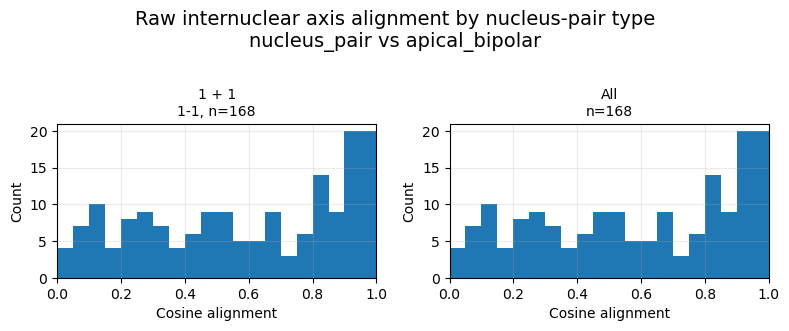

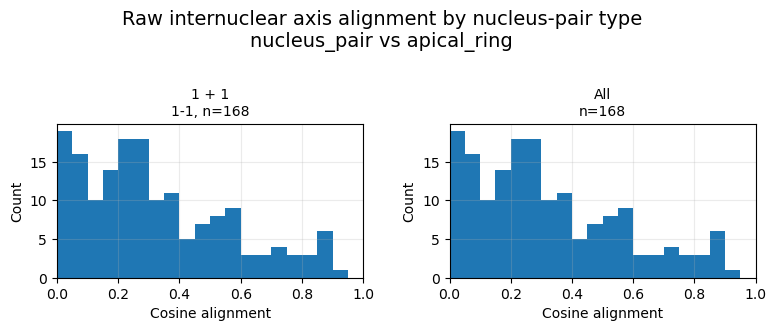

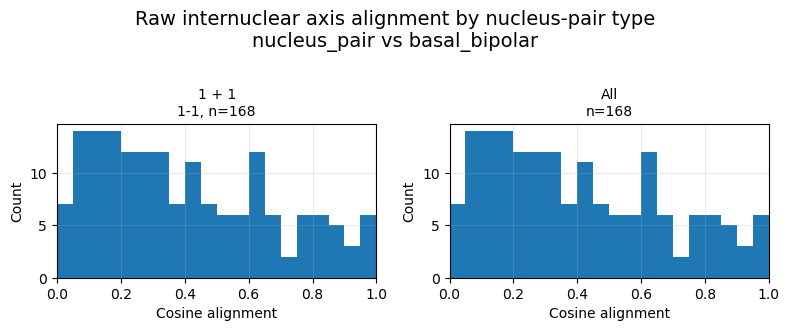

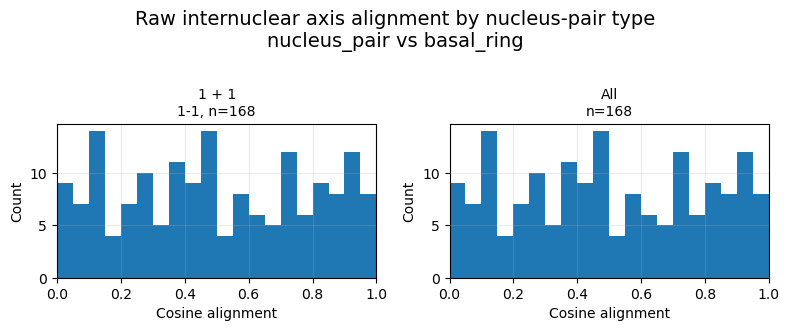

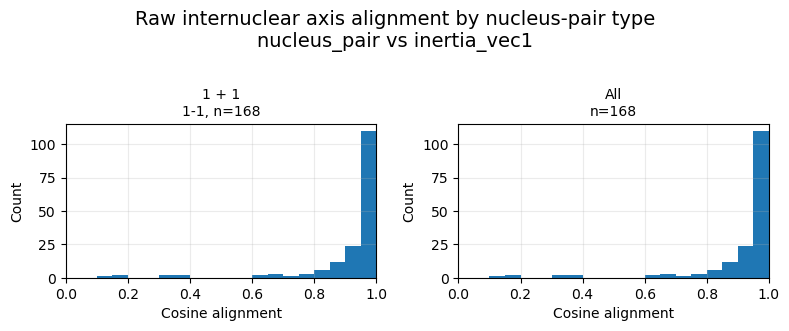

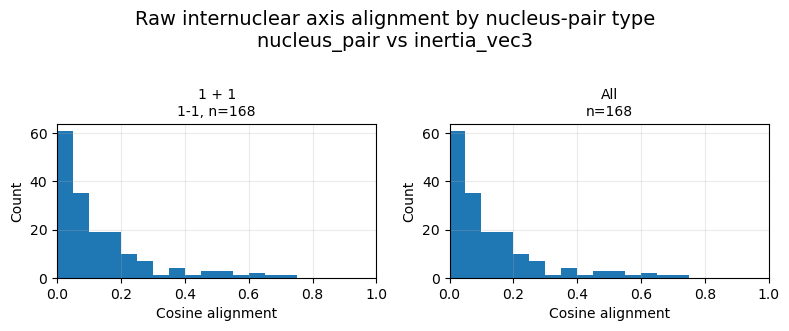

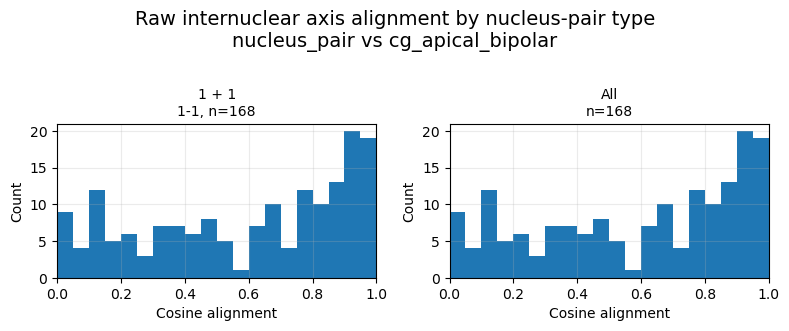

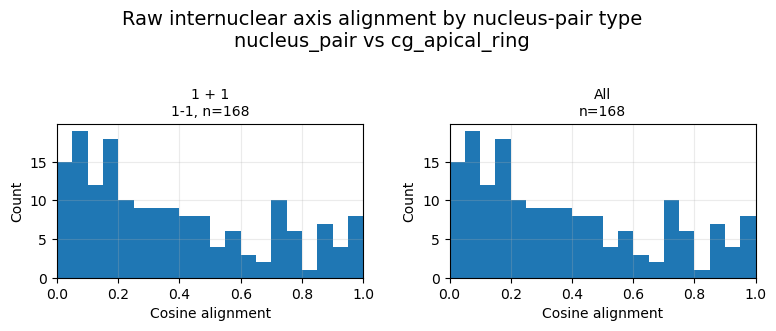

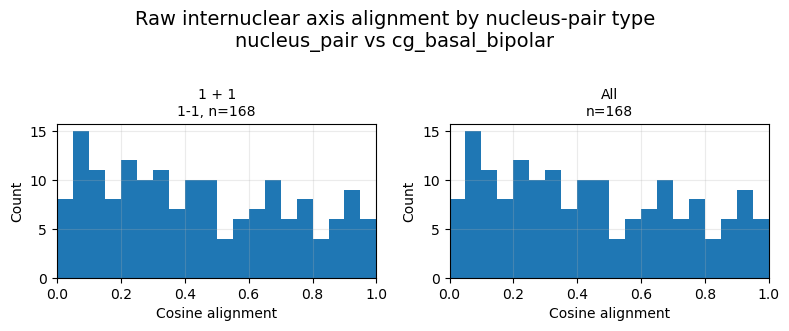

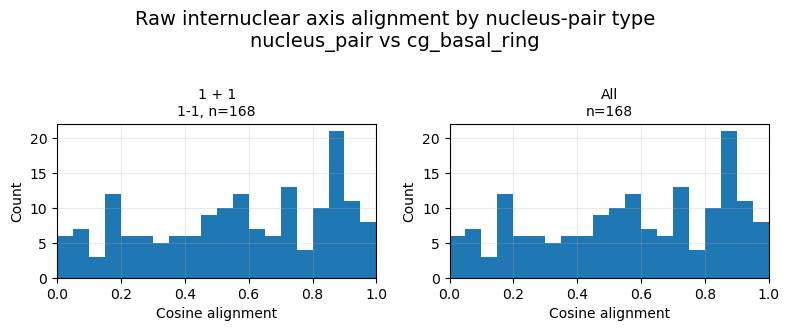

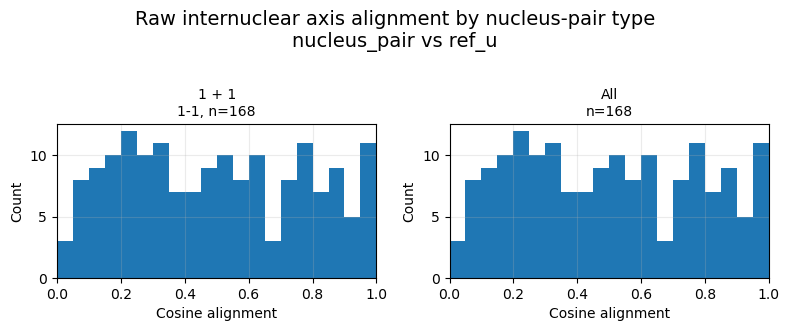

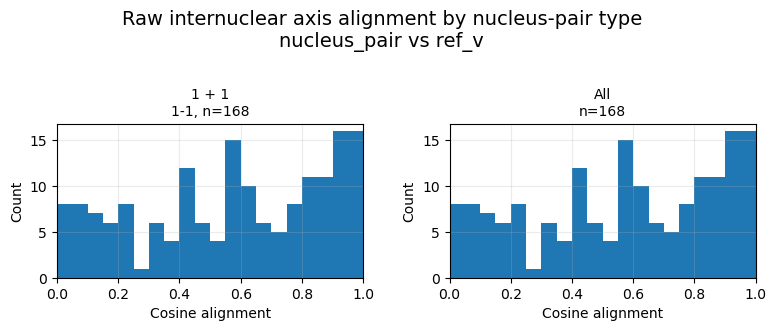

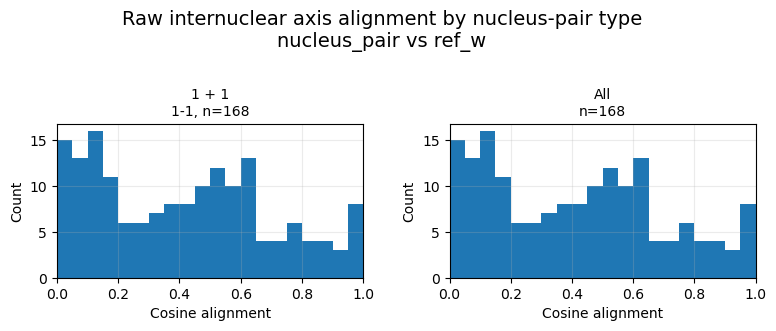


Coarse-grained internuclear axis alignment by nucleus-pair type


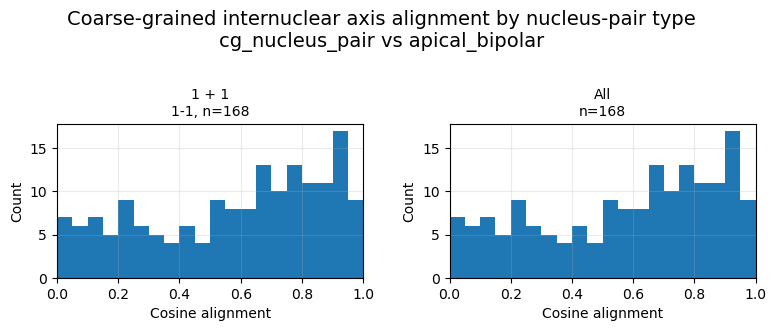

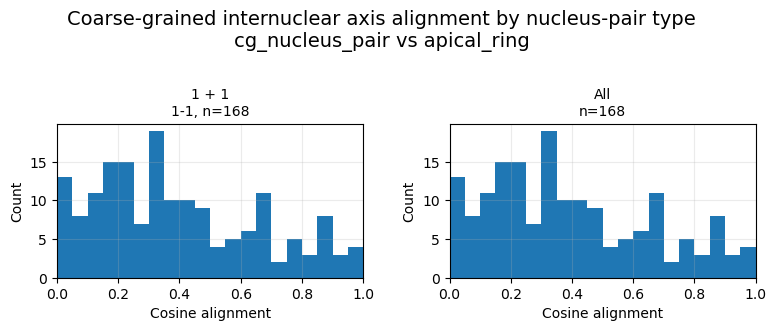

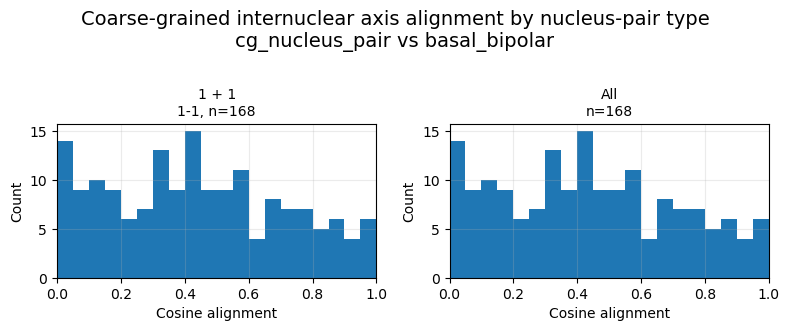

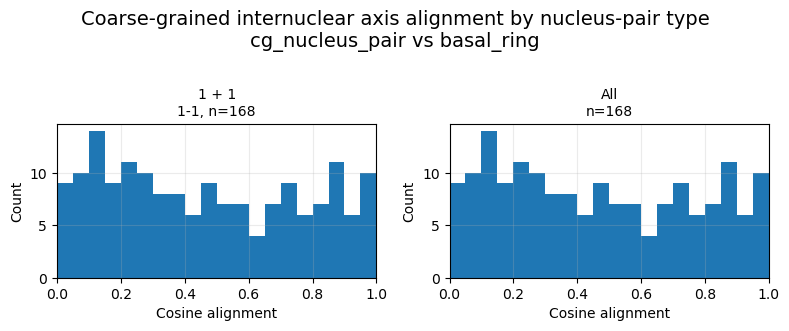

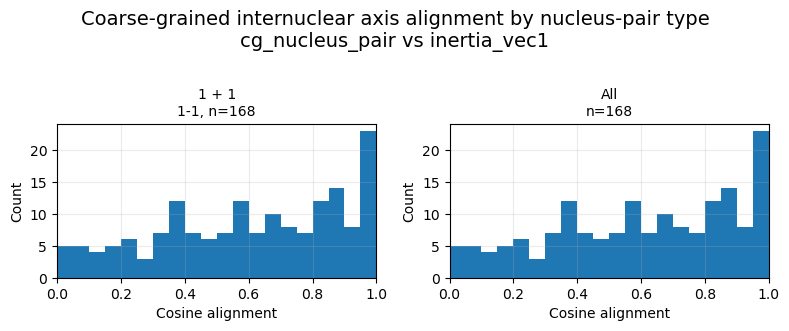

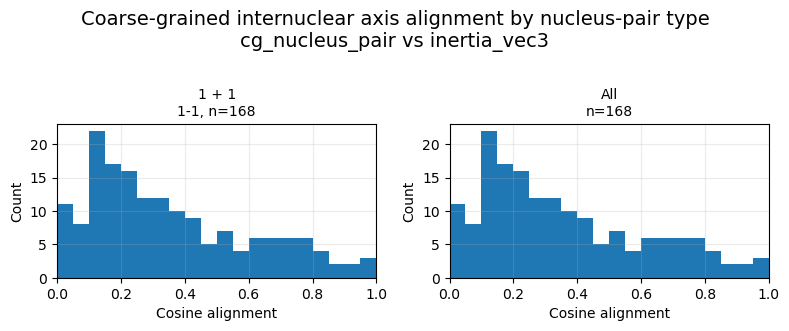

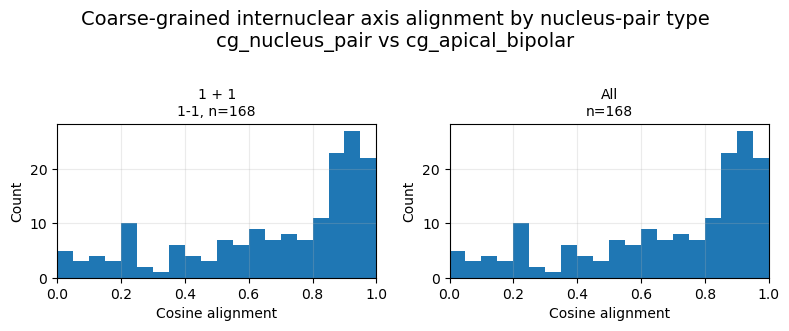

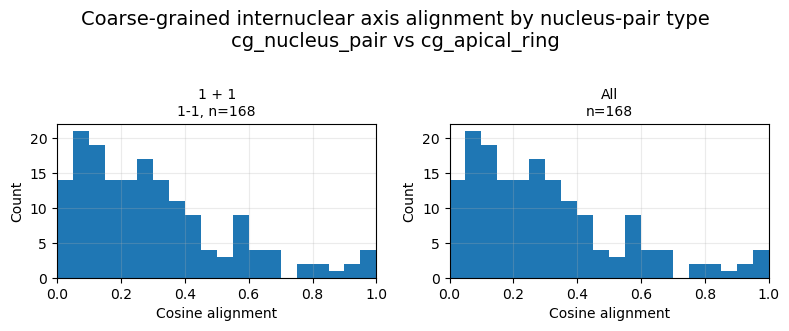

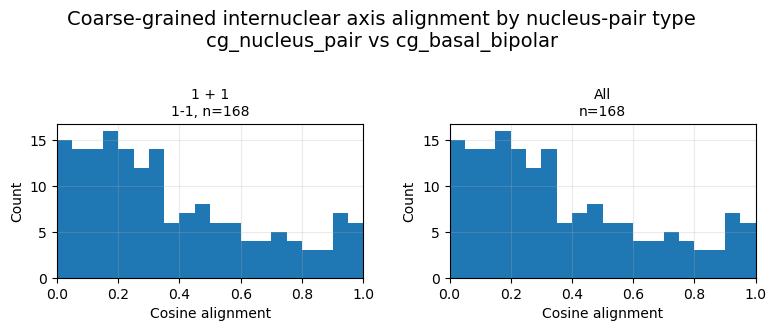

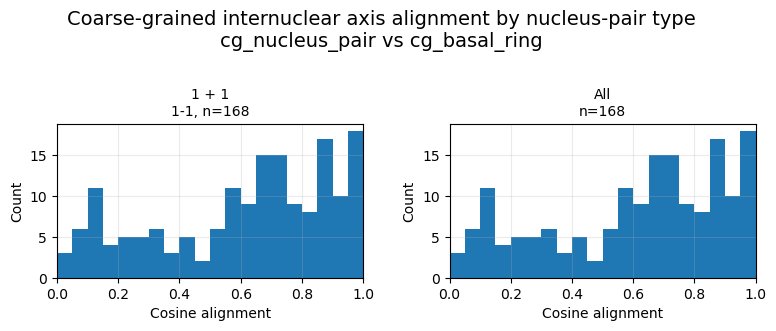

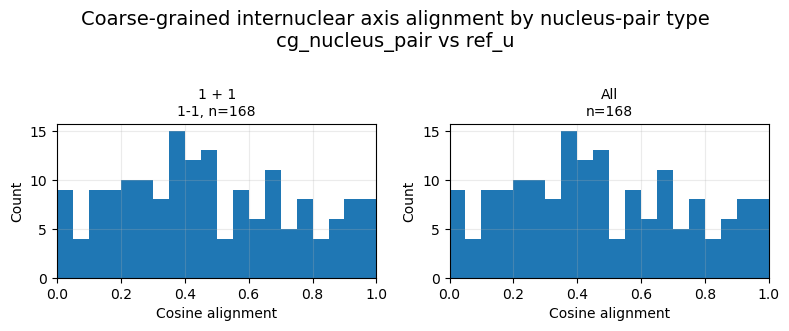

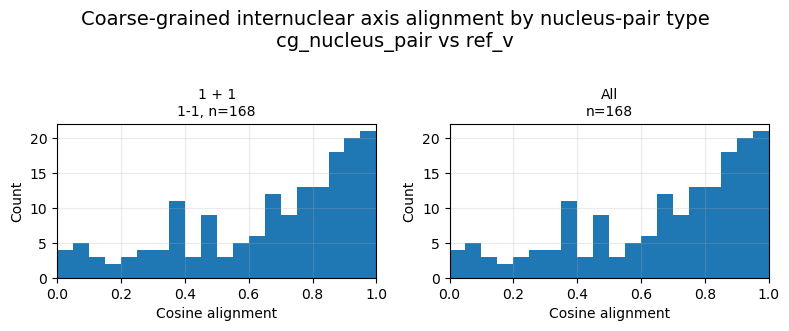

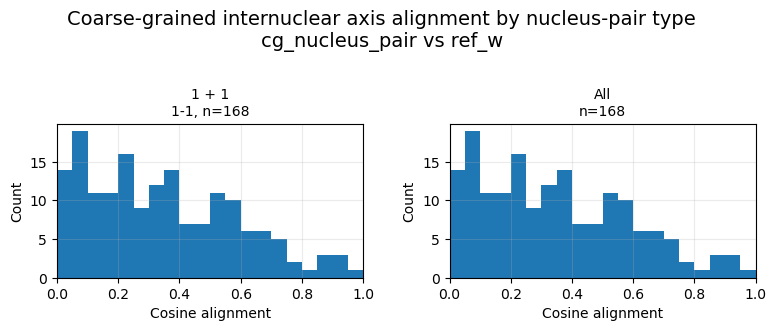

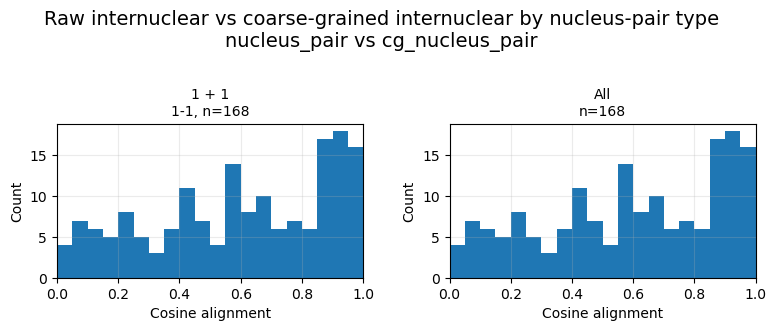

In [17]:
# =========================
# Block 13I-2 — Grouped histograms for raw and coarse-grained internuclear alignment
# =========================

HIST_BINS = 20
HIST_MAX_COLS = 4
HIST_MIN_GROUP_COUNT = 1


def find_cosine_column(df, axis_a, axis_b):
    """
    Find cosine-feature column independent of axis order.
    """
    col_ab = f"cos_{axis_a}__{axis_b}"
    col_ba = f"cos_{axis_b}__{axis_a}"

    if col_ab in df.columns:
        return col_ab
    if col_ba in df.columns:
        return col_ba

    return None


def get_pair_type_display_name(df, pair_type_label):
    """
    Get a readable name for one nuclear-pair type.
    """
    values = (
        df.loc[
            df["nucleus_pair_type_label"] == pair_type_label,
            "nucleus_pair_type_short",
        ]
        .dropna()
        .unique()
    )

    if len(values) == 0:
        return str(pair_type_label)

    return str(values[0])


def plot_grouped_alignment_histogram_grid(
    df,
    target_axis,
    comparison_axis,
    title_prefix,
    bins=20,
    max_cols=4,
    min_group_count=1,
):
    """
    Plot cosine-alignment histograms split by nucleus-pair type,
    plus one final 'All' panel.
    """
    col = find_cosine_column(df, target_axis, comparison_axis)

    if col is None:
        print(f"Missing column for {target_axis} vs {comparison_axis}. Skipping.")
        return

    required_cols = [
        "cell_id",
        col,
        "nucleus_pair_type_label",
        "nucleus_pair_type_short",
    ]

    plot_df = df[required_cols].copy()
    plot_df = plot_df.dropna(subset=[col])
    plot_df = plot_df[plot_df["nucleus_pair_type_label"].notna()].copy()

    if len(plot_df) == 0:
        print(f"No valid values for {col}. Skipping.")
        return

    group_counts = plot_df["nucleus_pair_type_label"].value_counts()

    group_labels = [
        label
        for label in sorted(group_counts.index)
        if group_counts[label] >= min_group_count
    ]

    if len(group_labels) == 0:
        print(f"No groups passed min_group_count for {col}. Skipping.")
        return

    panels = []

    for label in group_labels:
        values = plot_df.loc[
            plot_df["nucleus_pair_type_label"] == label,
            col,
        ].dropna()

        display_name = get_pair_type_display_name(plot_df, label)

        panels.append({
            "label": label,
            "title": f"{display_name}\n{label}, n={len(values)}",
            "values": values,
        })

    # Final total panel: all internuclear vectors together
    all_values = plot_df[col].dropna()

    panels.append({
        "label": "All",
        "title": f"All\nn={len(all_values)}",
        "values": all_values,
    })

    n_panels = len(panels)
    n_cols = min(max_cols, n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.0 * n_cols, 3.2 * n_rows),
        squeeze=False,
    )

    fig.suptitle(
        f"{title_prefix}\n{target_axis} vs {comparison_axis}",
        fontsize=14,
        y=1.02,
    )

    for ax, panel in zip(axes.flat, panels):
        values = panel["values"]

        ax.hist(
            values,
            bins=bins,
            range=(0.0, 1.0),
        )

        ax.set_title(panel["title"], fontsize=10)
        ax.set_xlim(0.0, 1.0)
        ax.set_xlabel("Cosine alignment")
        ax.set_ylabel("Count")
        ax.grid(alpha=0.25)

    # Hide unused axes
    for ax in axes.flat[n_panels:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def plot_grouped_alignment_histograms(
    df,
    target_axis,
    comparison_axes,
    title_prefix,
    bins=20,
    max_cols=4,
    min_group_count=1,
):
    """
    Plot one grouped figure per comparison axis.
    """
    print("\n==============================")
    print(title_prefix)
    print("==============================")

    for comparison_axis in comparison_axes:
        plot_grouped_alignment_histogram_grid(
            df=df,
            target_axis=target_axis,
            comparison_axis=comparison_axis,
            title_prefix=title_prefix,
            bins=bins,
            max_cols=max_cols,
            min_group_count=min_group_count,
        )


# -------------------------
# Quick table of nuclear-pair types
# -------------------------
print("\n==============================")
print("Nucleus-pair types used for grouped histograms")
print("==============================")

display(
    cosine_features_df
    .loc[cosine_features_df["nucleus_pair_type_label"].notna()]
    .groupby([
        "nucleus_pair_type_label",
        "nucleus_pair_type_short",
        "nucleus_pair_type_name",
    ])
    .size()
    .reset_index(name="n_cells")
    .sort_values("nucleus_pair_type_label")
)


comparison_axes_for_nucleus = [
    # Raw apico-basal axes
    "apical_bipolar",
    "apical_ring",
    "basal_bipolar",
    "basal_ring",

    # Shape axes
    "inertia_vec1",
    "inertia_vec3",

    # Coarse-grained apico-basal fields
    "cg_apical_bipolar",
    "cg_apical_ring",
    "cg_basal_bipolar",
    "cg_basal_ring",

    # PV/CV reference frame
    "ref_u",
    "ref_v",
    "ref_w",
]


# Raw internuclear axis histograms, split by nuclear-pair type + All
plot_grouped_alignment_histograms(
    df=cosine_features_df,
    target_axis="nucleus_pair",
    comparison_axes=comparison_axes_for_nucleus,
    title_prefix="Raw internuclear axis alignment by nucleus-pair type",
    bins=HIST_BINS,
    max_cols=HIST_MAX_COLS,
    min_group_count=HIST_MIN_GROUP_COUNT,
)


# Coarse-grained internuclear axis histograms, split by nuclear-pair type + All
plot_grouped_alignment_histograms(
    df=cosine_features_df,
    target_axis="cg_nucleus_pair",
    comparison_axes=comparison_axes_for_nucleus,
    title_prefix="Coarse-grained internuclear axis alignment by nucleus-pair type",
    bins=HIST_BINS,
    max_cols=HIST_MAX_COLS,
    min_group_count=HIST_MIN_GROUP_COUNT,
)


# Optional direct comparison: raw internuclear vs CG internuclear,
# also split by the central cell's nuclear-pair type.
plot_grouped_alignment_histogram_grid(
    df=cosine_features_df,
    target_axis="nucleus_pair",
    comparison_axis="cg_nucleus_pair",
    title_prefix="Raw internuclear vs coarse-grained internuclear by nucleus-pair type",
    bins=HIST_BINS,
    max_cols=HIST_MAX_COLS,
    min_group_count=HIST_MIN_GROUP_COUNT,
)

In [18]:
# =========================
# Block 13J — Build final node feature table
# =========================

# -------------------------
# Basic helper functions
# -------------------------
def add_vector_to_row(row, prefix, vec):
    """
    Add a 3D vector to a row dictionary using z, y, x coordinates.
    """
    if vec is None:
        vec = np.full(3, np.nan)

    vec = np.asarray(vec, dtype=float)

    if vec.shape != (3,):
        vec = np.full(3, np.nan)

    row[f"{prefix}_z"] = vec[0]
    row[f"{prefix}_y"] = vec[1]
    row[f"{prefix}_x"] = vec[2]


def add_tensor_to_row(row, prefix, tensor):
    """
    Add a 3x3 tensor to a row dictionary using z, y, x coordinates.
    """
    tensor = np.asarray(tensor, dtype=float)

    if tensor.shape != (3, 3):
        tensor = np.full((3, 3), np.nan)

    coords = ["z", "y", "x"]

    for i, a in enumerate(coords):
        for j, b in enumerate(coords):
            row[f"{prefix}_{a}{b}"] = tensor[i, j]


def add_eigvals_to_row(row, prefix, eigvals):
    """
    Add three eigenvalues to a row dictionary.
    """
    eigvals = np.asarray(eigvals, dtype=float)

    if eigvals.shape != (3,):
        eigvals = np.full(3, np.nan)

    row[f"{prefix}_eigval_1"] = eigvals[0]
    row[f"{prefix}_eigval_2"] = eigvals[1]
    row[f"{prefix}_eigval_3"] = eigvals[2]


def get_first_available(d, keys, default=np.nan):
    """
    Return the first available value from a dictionary.
    """
    if d is None:
        return default

    for key in keys:
        if key in d:
            return d[key]

    return default


def safe_nanmean(values):
    """
    Return nanmean without warnings when all values are NaN or empty.
    """
    values = np.asarray(values, dtype=float)

    if len(values) == 0:
        return np.nan

    valid = np.isfinite(values)

    if not np.any(valid):
        return np.nan

    return float(np.nanmean(values))


def safe_nansum(values):
    """
    Return nansum, but NaN if the list is empty or fully NaN.
    """
    values = np.asarray(values, dtype=float)

    if len(values) == 0:
        return np.nan

    valid = np.isfinite(values)

    if not np.any(valid):
        return np.nan

    return float(np.nansum(values))


# -------------------------
# Nucleus type definitions
# -------------------------
if "NUCLEUS_TYPE_LABELS" not in globals():
    NUCLEUS_TYPE_LABELS = {
        100: "normal_hepatocyte_nucleus",
        200: "metaphase",
        300: "anaphase_telophase",
        400: "cytokinesis",
    }

NUCLEUS_TYPE_SHORT_LABELS = {
    100: "normal",
    200: "metaphase",
    300: "anaphase_telophase",
    400: "cytokinesis",
}


# -------------------------
# Fallback pair-type helper, only used if not already defined
# -------------------------
if "get_nucleus_pair_type_from_cell_data" not in globals():

    def get_nucleus_pair_type_from_cell_data(cell_entry):
        """
        Return a canonical nuclear-pair type for cells with exactly two nuclei.

        The pair is sorted, so 100-200 and 200-100 are treated as the same type.
        """
        output = {
            "nucleus_pair_type_label": np.nan,
            "nucleus_pair_type_name": np.nan,
            "nucleus_pair_type_short": np.nan,
            "nucleus_pair_is_mixed_type": np.nan,
        }

        nuclei_info = cell_entry.get("nuclei", {})

        if nuclei_info is None:
            return output

        if not nuclei_info.get("has_nucleus_pair_vector", False):
            return output

        nuclei_list = nuclei_info.get("nuclei", [])

        if nuclei_list is None or len(nuclei_list) != 2:
            return output

        labels = []

        for nuc in nuclei_list:
            label = nuc.get("type_label", np.nan)

            if pd.isna(label):
                return output

            labels.append(int(label))

        labels = sorted(labels)

        type_names = [
            NUCLEUS_TYPE_LABELS.get(label, str(label))
            for label in labels
        ]

        type_shorts = [
            NUCLEUS_TYPE_SHORT_LABELS.get(label, str(label))
            for label in labels
        ]

        output["nucleus_pair_type_label"] = f"{labels[0]}-{labels[1]}"
        output["nucleus_pair_type_name"] = f"{type_names[0]} + {type_names[1]}"
        output["nucleus_pair_type_short"] = f"{type_shorts[0]} + {type_shorts[1]}"
        output["nucleus_pair_is_mixed_type"] = labels[0] != labels[1]

        return output


# -------------------------
# Cell geometry features
# -------------------------
def add_cell_geometry_features(row, cid, data, cell_meshes):
    """
    Add basic cell geometry features.
    """
    mesh = cell_meshes.get(cid, None)

    if mesh is None:
        row["cell_volume"] = np.nan
        row["cell_surface_area"] = np.nan
        row["cell_n_vertices"] = np.nan
        row["cell_n_faces"] = np.nan
        add_vector_to_row(row, "cell_mesh_centroid", np.full(3, np.nan))
        add_vector_to_row(row, "cell_mesh_center_mass", np.full(3, np.nan))
        add_vector_to_row(row, "cell_topology_centroid", data.get("centroid", np.full(3, np.nan)))
        return

    row["cell_volume"] = float(mesh.volume)
    row["cell_surface_area"] = float(mesh.area)
    row["cell_n_vertices"] = int(len(mesh.vertices))
    row["cell_n_faces"] = int(len(mesh.faces))

    add_vector_to_row(row, "cell_mesh_centroid", mesh.centroid)

    try:
        add_vector_to_row(row, "cell_mesh_center_mass", mesh.center_mass)
    except Exception:
        add_vector_to_row(row, "cell_mesh_center_mass", np.full(3, np.nan))

    add_vector_to_row(
        row,
        "cell_topology_centroid",
        data.get("centroid", np.full(3, np.nan)),
    )


# -------------------------
# Contact area features
# -------------------------
def add_contact_area_features(row, data):
    """
    Add topological contact area features.
    """
    area_apical = data.get("area_apical", np.nan)
    area_basal = data.get("area_basal", np.nan)
    area_lateral = data.get("area_lateral", np.nan)
    area_border = data.get("area_border", np.nan)
    area_void = data.get("area_void", np.nan)
    area_cv = data.get("area_cv", np.nan)
    area_pv = data.get("area_pv", np.nan)

    area_total_mapped = np.nansum([
        area_apical,
        area_basal,
        area_lateral,
        area_border,
        area_void,
        area_cv,
        area_pv,
    ])

    row["area_apical"] = area_apical
    row["area_basal"] = area_basal
    row["area_lateral"] = area_lateral
    row["area_border"] = area_border
    row["area_void"] = area_void
    row["area_cv"] = area_cv
    row["area_pv"] = area_pv
    row["area_total_mapped"] = area_total_mapped

    if area_total_mapped > 0:
        row["frac_apical"] = area_apical / area_total_mapped
        row["frac_basal"] = area_basal / area_total_mapped
        row["frac_lateral"] = area_lateral / area_total_mapped
        row["frac_border"] = area_border / area_total_mapped
        row["frac_void"] = area_void / area_total_mapped
        row["frac_cv"] = area_cv / area_total_mapped
        row["frac_pv"] = area_pv / area_total_mapped
    else:
        row["frac_apical"] = np.nan
        row["frac_basal"] = np.nan
        row["frac_lateral"] = np.nan
        row["frac_border"] = np.nan
        row["frac_void"] = np.nan
        row["frac_cv"] = np.nan
        row["frac_pv"] = np.nan


# -------------------------
# Nuclear features
# -------------------------
def add_single_nucleus_features(row, nucleus, prefix):
    """
    Add compact features for one nucleus.

    Stored per nucleus:
    - ID
    - type label
    - type name
    - volume
    - area
    - mesh centroid z/y/x only

    No full nucleus mesh is stored.
    No voxel centroid or center of mass is stored.
    """
    if nucleus is None:
        nucleus = {}

    row[f"{prefix}_id"] = get_first_available(
        nucleus,
        ["nucleus_id", "id", "label_id"],
        default=np.nan,
    )

    row[f"{prefix}_type_label"] = get_first_available(
        nucleus,
        ["type_label", "nucleus_type", "raw_label"],
        default=np.nan,
    )

    row[f"{prefix}_type_name"] = get_first_available(
        nucleus,
        ["type_name"],
        default=np.nan,
    )

    row[f"{prefix}_volume"] = get_first_available(
        nucleus,
        ["mesh_volume", "volume"],
        default=np.nan,
    )

    row[f"{prefix}_area"] = get_first_available(
        nucleus,
        ["mesh_area", "area", "surface_area"],
        default=np.nan,
    )

    add_vector_to_row(
        row,
        f"{prefix}_mesh_centroid",
        get_first_available(
            nucleus,
            ["mesh_centroid_zyx", "mesh_centroid"],
            default=np.full(3, np.nan),
        ),
    )


def add_nuclear_features(row, nuclei_info):
    """
    Add compact nuclear features for cells with any number of nuclei.

    Rules:
    - If n_nuclei == 2, keep the internuclear vector from Block 10.
    - If n_nuclei != 2, internuclear vector columns are NaN / False.
    - For all cells, store every nucleus as nucleus_1, nucleus_2, nucleus_3, ...
    - For each nucleus, store only ID, type, volume, area, and mesh centroid.
    - Store counts and fractions of each nuclear type per node.
    """
    if nuclei_info is None:
        nuclei_info = {}

    nuclei_list = nuclei_info.get("nuclei", [])

    if nuclei_list is None:
        nuclei_list = []

    n_nuclei = int(nuclei_info.get("n_nuclei", len(nuclei_list)))

    row["n_nuclei"] = n_nuclei
    row["has_more_than_two_nuclei"] = n_nuclei > 2

    # -------------------------
    # Internuclear vector features
    # -------------------------
    # Block 10 already defines these only for exactly two nuclei.
    has_pair_vector = bool(nuclei_info.get("has_nucleus_pair_vector", False))

    row["has_nucleus_pair_vector"] = has_pair_vector
    row["nucleus_pair_distance"] = nuclei_info.get("nucleus_pair_distance", np.nan)

    if has_pair_vector:
        pair_axis = nuclei_info.get("nucleus_pair_unit_vector_zyx", np.full(3, np.nan))
        pair_vector = nuclei_info.get("nucleus_pair_vector_zyx", np.full(3, np.nan))
    else:
        pair_axis = np.full(3, np.nan)
        pair_vector = np.full(3, np.nan)

    add_vector_to_row(row, "nucleus_pair_axis", pair_axis)
    add_vector_to_row(row, "nucleus_pair_vector", pair_vector)

    # -------------------------
    # Type counts and fractions
    # -------------------------
    type_labels = []

    for nucleus in nuclei_list:
        type_label = get_first_available(
            nucleus,
            ["type_label", "nucleus_type", "raw_label"],
            default=np.nan,
        )

        if pd.isna(type_label):
            type_labels.append(np.nan)
        else:
            type_labels.append(int(type_label))

    for label_value, short_name in NUCLEUS_TYPE_SHORT_LABELS.items():
        count = int(sum(label == label_value for label in type_labels))

        row[f"n_{short_name}"] = count

        if n_nuclei > 0:
            row[f"frac_{short_name}"] = count / n_nuclei
        else:
            row[f"frac_{short_name}"] = np.nan

    # -------------------------
    # Individual nucleus features
    # -------------------------
    nucleus_volumes = []
    nucleus_areas = []

    for idx, nucleus in enumerate(nuclei_list, start=1):
        prefix = f"nucleus_{idx}"

        add_single_nucleus_features(
            row=row,
            nucleus=nucleus,
            prefix=prefix,
        )

        nucleus_volumes.append(
            get_first_available(
                nucleus,
                ["mesh_volume", "volume"],
                default=np.nan,
            )
        )

        nucleus_areas.append(
            get_first_available(
                nucleus,
                ["mesh_area", "area", "surface_area"],
                default=np.nan,
            )
        )

    # -------------------------
    # Overall nuclear volume / area summaries
    # -------------------------
    row["nucleus_volume_sum"] = safe_nansum(nucleus_volumes)
    row["nucleus_volume_mean"] = safe_nanmean(nucleus_volumes)

    row["nucleus_area_sum"] = safe_nansum(nucleus_areas)
    row["nucleus_area_mean"] = safe_nanmean(nucleus_areas)

    # -------------------------
    # Per-type volume / area summaries
    # -------------------------
    for label_value, short_name in NUCLEUS_TYPE_SHORT_LABELS.items():

        idx_this_type = [
            i for i, label in enumerate(type_labels)
            if label == label_value
        ]

        volumes_this_type = [
            nucleus_volumes[i]
            for i in idx_this_type
        ]

        areas_this_type = [
            nucleus_areas[i]
            for i in idx_this_type
        ]

        row[f"{short_name}_nucleus_volume_sum"] = safe_nansum(volumes_this_type)
        row[f"{short_name}_nucleus_volume_mean"] = safe_nanmean(volumes_this_type)

        row[f"{short_name}_nucleus_area_sum"] = safe_nansum(areas_this_type)
        row[f"{short_name}_nucleus_area_mean"] = safe_nanmean(areas_this_type)


# -------------------------
# Raw tensor features
# -------------------------
def add_nematic_features(row, prefix, block):
    """
    Add raw nematic tensor features.
    """
    if block is None:
        block = {}

    row[f"{prefix}_valid"] = block.get("valid", False)
    row[f"{prefix}_n_faces"] = block.get("n_faces", np.nan)
    row[f"{prefix}_spherical_area"] = block.get("spherical_area", np.nan)

    add_tensor_to_row(
        row,
        f"{prefix}_tensor",
        block.get("tensor", np.full((3, 3), np.nan)),
    )

    add_eigvals_to_row(
        row,
        prefix,
        block.get("eigvals", np.full(3, np.nan)),
    )

    add_vector_to_row(
        row,
        f"{prefix}_bipolar_axis",
        block.get("bipolar_axis", np.full(3, np.nan)),
    )

    add_vector_to_row(
        row,
        f"{prefix}_ring_axis",
        block.get("ring_axis", np.full(3, np.nan)),
    )


def add_inertia_features(row, prefix, block):
    """
    Add inertia tensor features.
    """
    if block is None:
        block = {}

    row[f"{prefix}_valid"] = block.get("valid", False)

    add_tensor_to_row(
        row,
        f"{prefix}_tensor",
        block.get("tensor", np.full((3, 3), np.nan)),
    )

    add_eigvals_to_row(
        row,
        prefix,
        block.get("eigvals", np.full(3, np.nan)),
    )

    add_vector_to_row(
        row,
        f"{prefix}_vec1",
        block.get("vec1", np.full(3, np.nan)),
    )

    add_vector_to_row(
        row,
        f"{prefix}_vec3",
        block.get("vec3", np.full(3, np.nan)),
    )


def add_cg_features(row, prefix, block):
    """
    Add coarse-grained tensor features.
    """
    if block is None:
        block = {}

    row[f"{prefix}_valid"] = block.get("valid", False)
    row[f"{prefix}_total_weight"] = block.get("total_weight", np.nan)
    row[f"{prefix}_n_neighbors_used"] = block.get("n_neighbors_used", np.nan)

    add_tensor_to_row(
        row,
        f"{prefix}_tensor",
        block.get("tensor", np.full((3, 3), np.nan)),
    )

    add_eigvals_to_row(
        row,
        prefix,
        block.get("eigvals", np.full(3, np.nan)),
    )

    add_vector_to_row(
        row,
        f"{prefix}_vec1",
        block.get("vec1", np.full(3, np.nan)),
    )

    add_vector_to_row(
        row,
        f"{prefix}_vec3",
        block.get("vec3", np.full(3, np.nan)),
    )


# -------------------------
# Reference-frame features
# -------------------------
def add_reference_features(row, ref):
    """
    Add PV/CV reference-frame features.
    """
    if ref is None:
        ref = {}

    row["reference_valid"] = ref.get("valid", False)
    row["reference_J_norm"] = ref.get("J_norm", np.nan)

    add_vector_to_row(row, "reference_J", ref.get("J", np.full(3, np.nan)))
    add_vector_to_row(row, "reference_u", ref.get("u", np.full(3, np.nan)))
    add_vector_to_row(row, "reference_v", ref.get("v", np.full(3, np.nan)))
    add_vector_to_row(row, "reference_w", ref.get("w", np.full(3, np.nan)))


def add_portal_central_position_features(row, pc):
    """
    Add nearest-distance portal-central coordinate features.

    chi_cv_to_pv:
        0 = near central vein
        1 = near portal vein
    """
    if pc is None:
        pc = {}

    row["portal_central_valid"] = pc.get("valid", False)

    row["d_cv_nearest_surface"] = pc.get("d_cv", np.nan)
    row["d_pv_nearest_surface"] = pc.get("d_pv", np.nan)

    row["chi_cv_to_pv"] = pc.get("chi_cv_to_pv", np.nan)

    chi = pc.get("chi_cv_to_pv", np.nan)
    row["chi_pv_to_cv"] = 1.0 - chi if np.isfinite(chi) else np.nan

    row["nearest_cv_triangle_index"] = pc.get("nearest_cv_triangle_index", -1)
    row["nearest_pv_triangle_index"] = pc.get("nearest_pv_triangle_index", -1)

    add_vector_to_row(
        row,
        "nearest_cv_point",
        pc.get("nearest_cv_point", np.full(3, np.nan)),
    )

    add_vector_to_row(
        row,
        "nearest_pv_point",
        pc.get("nearest_pv_point", np.full(3, np.nan)),
    )


# =========================
# Build final node feature table
# =========================
feature_rows = []

for cid in valid_analysis_ids:

    data = cell_data[cid]

    row = {}

    # -------------------------
    # Identity and filtering flags
    # -------------------------
    row["cell_id"] = int(cid)
    row["use_for_physics"] = data.get("use_for_physics", False)
    row["use_for_graph"] = data.get("use_for_graph", False)
    row["is_border_cell"] = data.get("is_border_cell", False)
    row["has_more_than_two_nuclei"] = data.get("has_more_than_two_nuclei", False)

    # -------------------------
    # Cell geometry
    # -------------------------
    add_cell_geometry_features(row, cid, data, cell_meshes)

    # -------------------------
    # Tensor projection center
    # -------------------------
    physics_raw = data.get("physics_raw", {})

    add_vector_to_row(
        row,
        "projection_center",
        physics_raw.get("projection_center", np.full(3, np.nan)),
    )

    # -------------------------
    # Contact topology
    # -------------------------
    add_contact_area_features(row, data)

    # -------------------------
    # Nuclear features
    # -------------------------
    add_nuclear_features(row, data.get("nuclei", {}))

    # -------------------------
    # Raw physical tensors
    # -------------------------
    add_nematic_features(row, "apical", physics_raw.get("apical", {}))
    add_nematic_features(row, "basal", physics_raw.get("basal", {}))
    add_inertia_features(row, "inertia", physics_raw.get("inertia", {}))

    # -------------------------
    # Coarse-grained physical tensors
    # -------------------------
    physics_cg = data.get("physics_cg", {})

    add_cg_features(row, "cg_apical_bipolar", physics_cg.get("apical_bipolar", {}))
    add_cg_features(row, "cg_apical_ring", physics_cg.get("apical_ring", {}))

    add_cg_features(row, "cg_basal_bipolar", physics_cg.get("basal_bipolar", {}))
    add_cg_features(row, "cg_basal_ring", physics_cg.get("basal_ring", {}))

    add_cg_features(row, "cg_inertia_vec1", physics_cg.get("inertia_vec1", {}))
    add_cg_features(row, "cg_inertia_vec3", physics_cg.get("inertia_vec3", {}))

    add_cg_features(row, "cg_nucleus_pair", physics_cg.get("nucleus_pair", {}))

    # -------------------------
    # PV/CV reference frame
    # -------------------------
    add_reference_features(row, data.get("reference_frame", {}))

    # -------------------------
    # Nearest-distance portal-central coordinate
    # -------------------------
    add_portal_central_position_features(
        row,
        data.get("portal_central_position", {}),
    )

    # -------------------------
    # Axes used for cosine features
    # -------------------------
    axis_features = data.get("axis_features", {})

    for axis_name, axis_value in axis_features.items():
        add_vector_to_row(row, f"axis_{axis_name}", axis_value)

    # -------------------------
    # Cosine alignment features
    # -------------------------
    cosine_features = data.get("cosine_features", {})

    for key, value in cosine_features.items():
        row[key] = value

    feature_rows.append(row)


cell_features_df = pd.DataFrame(feature_rows)


# -------------------------
# Add canonical nucleus-pair type columns to the node feature table
# -------------------------
nucleus_pair_type_rows_for_features = []

for cid in valid_analysis_ids:
    pair_info = get_nucleus_pair_type_from_cell_data(cell_data[cid])
    pair_info["cell_id"] = int(cid)
    nucleus_pair_type_rows_for_features.append(pair_info)

nucleus_pair_type_df = pd.DataFrame(nucleus_pair_type_rows_for_features)

pair_type_cols = [
    "nucleus_pair_type_label",
    "nucleus_pair_type_name",
    "nucleus_pair_type_short",
    "nucleus_pair_is_mixed_type",
]

cell_features_df = cell_features_df.drop(
    columns=pair_type_cols,
    errors="ignore",
)

cell_features_df = cell_features_df.merge(
    nucleus_pair_type_df[["cell_id"] + pair_type_cols],
    on="cell_id",
    how="left",
)


# -------------------------
# Put the most important columns first
# -------------------------
core_cols = [
    "cell_id",
    "use_for_physics",
    "use_for_graph",
    "is_border_cell",
    "has_more_than_two_nuclei",

    "cell_volume",
    "cell_surface_area",
    "cell_n_vertices",
    "cell_n_faces",

    "cell_mesh_centroid_z",
    "cell_mesh_centroid_y",
    "cell_mesh_centroid_x",

    "projection_center_z",
    "projection_center_y",
    "projection_center_x",

    "portal_central_valid",
    "d_cv_nearest_surface",
    "d_pv_nearest_surface",
    "chi_cv_to_pv",
    "chi_pv_to_cv",

    "n_nuclei",

    "n_normal",
    "n_metaphase",
    "n_anaphase_telophase",
    "n_cytokinesis",

    "frac_normal",
    "frac_metaphase",
    "frac_anaphase_telophase",
    "frac_cytokinesis",

    "has_nucleus_pair_vector",
    "nucleus_pair_distance",

    "nucleus_pair_axis_z",
    "nucleus_pair_axis_y",
    "nucleus_pair_axis_x",

    "nucleus_pair_vector_z",
    "nucleus_pair_vector_y",
    "nucleus_pair_vector_x",

    "nucleus_pair_type_label",
    "nucleus_pair_type_name",
    "nucleus_pair_type_short",
    "nucleus_pair_is_mixed_type",

    "nucleus_volume_sum",
    "nucleus_volume_mean",
    "nucleus_area_sum",
    "nucleus_area_mean",

    "normal_nucleus_volume_sum",
    "normal_nucleus_volume_mean",
    "normal_nucleus_area_sum",
    "normal_nucleus_area_mean",

    "metaphase_nucleus_volume_sum",
    "metaphase_nucleus_volume_mean",
    "metaphase_nucleus_area_sum",
    "metaphase_nucleus_area_mean",

    "anaphase_telophase_nucleus_volume_sum",
    "anaphase_telophase_nucleus_volume_mean",
    "anaphase_telophase_nucleus_area_sum",
    "anaphase_telophase_nucleus_area_mean",

    "cytokinesis_nucleus_volume_sum",
    "cytokinesis_nucleus_volume_mean",
    "cytokinesis_nucleus_area_sum",
    "cytokinesis_nucleus_area_mean",

    "area_apical",
    "area_basal",
    "area_lateral",
    "area_void",
    "area_cv",
    "area_pv",
    "area_border",
    "area_total_mapped",

    "frac_apical",
    "frac_basal",
    "frac_lateral",
    "frac_void",
    "frac_cv",
    "frac_pv",
    "frac_border",
]

# Dynamic per-nucleus columns: nucleus_1_..., nucleus_2_..., nucleus_3_..., etc.
nucleus_detail_cols = []

nucleus_prefixes = sorted(
    {
        col.split("_id")[0]
        for col in cell_features_df.columns
        if col.startswith("nucleus_") and col.endswith("_id")
    },
    key=lambda x: int(x.split("_")[1]) if x.split("_")[1].isdigit() else 9999,
)

for prefix in nucleus_prefixes:
    nucleus_detail_cols.extend([
        f"{prefix}_id",
        f"{prefix}_type_label",
        f"{prefix}_type_name",
        f"{prefix}_volume",
        f"{prefix}_area",
        f"{prefix}_mesh_centroid_z",
        f"{prefix}_mesh_centroid_y",
        f"{prefix}_mesh_centroid_x",
    ])

first_cols = core_cols + nucleus_detail_cols
first_cols = [col for col in first_cols if col in cell_features_df.columns]

remaining_cols = [
    col for col in cell_features_df.columns
    if col not in first_cols
]

cell_features_df = cell_features_df[first_cols + remaining_cols]


# -------------------------
# Summary
# -------------------------
print("\n==============================")
print("Final node feature table summary")
print("==============================")
print("Rows / graph nodes:", cell_features_df.shape[0])
print("Columns / node features:", cell_features_df.shape[1])

print("\nNuclei counts:")
print(cell_features_df["n_nuclei"].value_counts(dropna=False).sort_index())

print("\nNucleus type counts across nodes:")
type_count_cols = [
    "n_normal",
    "n_metaphase",
    "n_anaphase_telophase",
    "n_cytokinesis",
]

for col in type_count_cols:
    if col in cell_features_df.columns:
        print(f"{col}: {int(cell_features_df[col].sum())}")

print("\nCells with >2 nuclei:")
if "has_more_than_two_nuclei" in cell_features_df.columns:
    print(int(cell_features_df["has_more_than_two_nuclei"].sum()))

print("\nNucleus-pair type counts:")
if "nucleus_pair_type_short" in cell_features_df.columns:
    display(
        cell_features_df
        .loc[cell_features_df["nucleus_pair_type_label"].notna()]
        .groupby([
            "nucleus_pair_type_label",
            "nucleus_pair_type_short",
            "nucleus_pair_type_name",
        ])
        .size()
        .reset_index(name="n_cells")
        .sort_values("nucleus_pair_type_label")
    )

print("\nMain validity counts:")
validity_cols = [
    "apical_valid",
    "basal_valid",
    "inertia_valid",

    "cg_apical_bipolar_valid",
    "cg_apical_ring_valid",

    "cg_basal_bipolar_valid",
    "cg_basal_ring_valid",

    "cg_inertia_vec1_valid",
    "cg_inertia_vec3_valid",

    "cg_nucleus_pair_valid",

    "reference_valid",
    "portal_central_valid",
]

for col in validity_cols:
    if col in cell_features_df.columns:
        print(f"{col}: {int(cell_features_df[col].sum())}")

print("\nPreview:")
display(cell_features_df.head())


Final node feature table summary
Rows / graph nodes: 860
Columns / node features: 699

Nuclei counts:
n_nuclei
0       9
1     675
2     168
3       2
5       2
6       1
7       1
17      1
25      1
Name: count, dtype: int64

Nucleus type counts across nodes:
n_normal: 0
n_metaphase: 0
n_anaphase_telophase: 0
n_cytokinesis: 0

Cells with >2 nuclei:
8

Nucleus-pair type counts:


,nucleus_pair_type_label,nucleus_pair_type_short,nucleus_pair_type_name,n_cells
0,1-1,1 + 1,hepatocyte_nucleus + hepatocyte_nucleus,168



Main validity counts:
apical_valid: 857
basal_valid: 859
inertia_valid: 860
cg_apical_bipolar_valid: 857
cg_apical_ring_valid: 857
cg_basal_bipolar_valid: 859
cg_basal_ring_valid: 859
cg_inertia_vec1_valid: 860
cg_inertia_vec3_valid: 860
cg_nucleus_pair_valid: 168
reference_valid: 860
portal_central_valid: 860

Preview:


,cell_id,use_for_physics,use_for_graph,is_border_cell,has_more_than_two_nuclei,cell_volume,cell_surface_area,cell_n_vertices,cell_n_faces,cell_mesh_centroid_z,...,cos_nucleus_pair__cg_nucleus_pair,cos_nucleus_pair__ref_u,cos_nucleus_pair__ref_v,cos_nucleus_pair__ref_w,cos_cg_nucleus_pair__ref_u,cos_cg_nucleus_pair__ref_v,cos_cg_nucleus_pair__ref_w,cos_ref_u__ref_v,cos_ref_u__ref_w,cos_ref_v__ref_w
0,20,True,True,False,False,550878.083333,43102.053774,58574,117152,66.333331,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.684503e-17,1.279261e-17,1.692170e-17
1,21,True,True,False,False,223553.625000,23469.634285,32565,65130,51.594479,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.790540e-18,2.182700e-17,7.666683e-17
2,22,True,True,False,True,428265.916667,37318.535014,51487,102982,92.793537,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.167056e-17,3.354646e-18,4.541054e-18
3,23,True,True,False,False,332191.166667,31792.127142,43057,86114,117.929430,...,0.576383,0.712812,0.290165,0.638516,0.881214,0.394557,0.260359,2.312638e-17,1.723580e-18,7.706592e-18
4,25,True,True,False,False,283099.916667,27452.536691,37317,74634,63.873943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.159039e-17,2.330101e-17,1.367225e-18


### Graph

In [19]:
# =========================
# Block 13K — Build final hepatocyte graph
# =========================

valid_set = set(int(cid) for cid in valid_analysis_ids)

special_contact_ids = {
    int(ID_BILE),
    int(ID_SINU),
    int(ID_BORDER),
    int(ID_CV),
    int(ID_PV),
}

G_hepatocytes = nx.Graph()

# -------------------------
# Add nodes with final node features
# -------------------------
node_feature_table = cell_features_df.set_index("cell_id")

for cid in valid_analysis_ids:
    cid = int(cid)

    if cid not in node_feature_table.index:
        print(f"Warning: cell {cid} not found in cell_features_df.")
        continue

    node_attrs = node_feature_table.loc[cid].to_dict()
    node_attrs["cell_id"] = cid

    G_hepatocytes.add_node(cid, **node_attrs)

print("Nodes added:", G_hepatocytes.number_of_nodes())


# -------------------------
# Add edges with only simple edge features
# -------------------------
for cid in tqdm(valid_analysis_ids, desc="Building graph edges"):

    cid = int(cid)

    face_labels = np.asarray(cell_data[cid]["face_labels"])
    face_areas = np.asarray(cell_data[cid]["face_areas"], dtype=float)

    neighbor_ids = np.unique(face_labels)

    for nid in neighbor_ids:
        nid = int(nid)

        # Keep only hepatocyte-hepatocyte contacts
        if nid == 0:
            continue

        if nid == cid:
            continue

        if nid in special_contact_ids:
            continue

        if nid not in valid_set:
            continue

        mask = face_labels == nid

        if not np.any(mask):
            continue

        contact_area = float(np.sum(face_areas[mask]))

        if contact_area <= 0:
            continue

        u, v = sorted([cid, nid])

        if not G_hepatocytes.has_edge(u, v):
            G_hepatocytes.add_edge(
                u,
                v,
                contact_area_total=0.0,
            )

        G_hepatocytes[u][v]["contact_area_total"] += contact_area


# -------------------------
# Add centroid distance to each edge
# -------------------------
for u, v, edge_data in G_hepatocytes.edges(data=True):

    center_u = np.array([
        G_hepatocytes.nodes[u]["projection_center_z"],
        G_hepatocytes.nodes[u]["projection_center_y"],
        G_hepatocytes.nodes[u]["projection_center_x"],
    ], dtype=float)

    center_v = np.array([
        G_hepatocytes.nodes[v]["projection_center_z"],
        G_hepatocytes.nodes[v]["projection_center_y"],
        G_hepatocytes.nodes[v]["projection_center_x"],
    ], dtype=float)

    centroid_distance = np.linalg.norm(center_v - center_u)

    edge_data["centroid_distance"] = float(centroid_distance)


# -------------------------
# Build simple edge feature table
# -------------------------
edge_rows = []

for u, v, edge_data in G_hepatocytes.edges(data=True):
    edge_rows.append({
        "cell_u": u,
        "cell_v": v,
        "contact_area_total": edge_data["contact_area_total"],
        "centroid_distance": edge_data["centroid_distance"],
    })

edge_features_df = pd.DataFrame(edge_rows)


# -------------------------
# Graph summary
# -------------------------
print("\n==============================")
print("Final hepatocyte graph summary")
print("==============================")
print("Nodes:", G_hepatocytes.number_of_nodes())
print("Edges:", G_hepatocytes.number_of_edges())

Nodes added: 860


Building graph edges:   0%|          | 0/860 [00:00<?, ?it/s]


Final hepatocyte graph summary
Nodes: 860
Edges: 3531


In [20]:
# =========================
# Block 14 — Export internuclear absolute-cosine alignments
# including raw/CG cross-comparisons
# =========================

from pathlib import Path

# -------------------------
# Output path
# -------------------------
OUTPUT_DIR = Path(
    "~/Alejandro_liver_graph/outputs/poster_figures/"
    "Muestra_elife/ang_pair_nucleus"
).expanduser()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Same file name as before.
# This will overwrite the previous file and avoid duplicates.
OUTPUT_FILE = OUTPUT_DIR / "internuclear_alignment_cosines.tsv"


# -------------------------
# Helper functions
# -------------------------
def get_axis_columns(axis_name):
    """
    Return the expected z, y, x columns for one stored axis.
    """
    return [
        f"axis_{axis_name}_z",
        f"axis_{axis_name}_y",
        f"axis_{axis_name}_x",
    ]


def axis_exists_in_df(df, axis_name):
    """
    Check whether a full z-y-x axis exists in the dataframe.
    """
    cols = get_axis_columns(axis_name)
    return all(col in df.columns for col in cols)


def compute_nematic_cosine_from_axis_columns(df, axis_a, axis_b):
    """
    Compute |dot(a,b)| from stored axis columns.

    This gives a nematic cosine alignment:
    1 = parallel
    0 = perpendicular

    No angle in degrees is computed here.
    """
    cols_a = get_axis_columns(axis_a)
    cols_b = get_axis_columns(axis_b)

    missing_cols = [
        col for col in cols_a + cols_b
        if col not in df.columns
    ]

    if len(missing_cols) > 0:
        print(f"Missing columns for {axis_a} vs {axis_b}:")
        print(missing_cols)
        return pd.Series(np.nan, index=df.index)

    A = df[cols_a].to_numpy(dtype=float)
    B = df[cols_b].to_numpy(dtype=float)

    A_norm = np.linalg.norm(A, axis=1)
    B_norm = np.linalg.norm(B, axis=1)

    valid = (
        np.isfinite(A).all(axis=1) &
        np.isfinite(B).all(axis=1) &
        (A_norm > 0) &
        (B_norm > 0)
    )

    cos_values = np.full(len(df), np.nan, dtype=float)

    A_unit = A[valid] / A_norm[valid, None]
    B_unit = B[valid] / B_norm[valid, None]

    cos_values[valid] = np.abs(np.sum(A_unit * B_unit, axis=1))
    cos_values = np.clip(cos_values, 0.0, 1.0)

    return pd.Series(cos_values, index=df.index)


def add_available_comparisons(
    comparisons,
    df,
    source_axis,
    target_axes,
    prefix_source_name,
    description_source_name,
):
    """
    Add comparisons from one source axis to a list of target axes,
    but only when all required columns exist.
    """
    if not axis_exists_in_df(df, source_axis):
        print(f"Warning: source axis not found: {source_axis}")
        return comparisons

    existing_prefixes = set(comp["prefix"] for comp in comparisons)

    for target_axis in target_axes:

        if not axis_exists_in_df(df, target_axis):
            print(f"Skipping missing target axis: {target_axis}")
            continue

        prefix = f"{prefix_source_name}_vs_{target_axis}"

        if prefix in existing_prefixes:
            continue

        comparisons.append({
            "prefix": prefix,
            "axis_a": source_axis,
            "axis_b": target_axis,
            "description": f"{description_source_name} vs {target_axis}",
        })

        existing_prefixes.add(prefix)

    return comparisons


# -------------------------
# Source table
# -------------------------
source_df = cell_features_df.copy()

# Keep only cells with a valid raw internuclear pair vector.
# These are binucleated cells with a defined internuclear axis.
if "has_nucleus_pair_vector" in source_df.columns:
    export_df = source_df[
        source_df["has_nucleus_pair_vector"] == True
    ].copy()
else:
    export_df = source_df.copy()

print("\n==============================")
print("Export internuclear absolute-cosine alignments")
print("==============================")
print("Input cells:", len(source_df))
print("Cells with internuclear vector:", len(export_df))


# -------------------------
# Axis groups
# -------------------------
raw_axes = [
    "apical_bipolar",
    "apical_ring",
    "basal_bipolar",
    "basal_ring",
    "inertia_vec1",
    "inertia_vec3",
]

cg_axes = [
    "cg_apical_bipolar",
    "cg_apical_ring",
    "cg_basal_bipolar",
    "cg_basal_ring",
    "cg_inertia_vec1",
    "cg_inertia_vec3",
]

reference_axes = [
    "ref_u",
    "ref_v",
    "ref_w",
]


# -------------------------
# Build comparison list
# -------------------------
comparisons = []

# 1) Raw internuclear axis vs raw cell axes
comparisons = add_available_comparisons(
    comparisons=comparisons,
    df=export_df,
    source_axis="nucleus_pair",
    target_axes=raw_axes,
    prefix_source_name="raw_nucleus_pair",
    description_source_name="Raw internuclear axis",
)

# 2) Raw internuclear axis vs CG cell axes
comparisons = add_available_comparisons(
    comparisons=comparisons,
    df=export_df,
    source_axis="nucleus_pair",
    target_axes=cg_axes,
    prefix_source_name="raw_nucleus_pair",
    description_source_name="Raw internuclear axis",
)

# 3) Raw internuclear axis vs reference axes
comparisons = add_available_comparisons(
    comparisons=comparisons,
    df=export_df,
    source_axis="nucleus_pair",
    target_axes=reference_axes,
    prefix_source_name="raw_nucleus_pair",
    description_source_name="Raw internuclear axis",
)

# 4) CG internuclear axis vs CG cell axes
comparisons = add_available_comparisons(
    comparisons=comparisons,
    df=export_df,
    source_axis="cg_nucleus_pair",
    target_axes=cg_axes,
    prefix_source_name="cg_nucleus_pair",
    description_source_name="Coarse-grained internuclear axis",
)

# 5) CG internuclear axis vs raw cell axes
comparisons = add_available_comparisons(
    comparisons=comparisons,
    df=export_df,
    source_axis="cg_nucleus_pair",
    target_axes=raw_axes,
    prefix_source_name="cg_nucleus_pair",
    description_source_name="Coarse-grained internuclear axis",
)

# 6) CG internuclear axis vs reference axes
comparisons = add_available_comparisons(
    comparisons=comparisons,
    df=export_df,
    source_axis="cg_nucleus_pair",
    target_axes=reference_axes,
    prefix_source_name="cg_nucleus_pair",
    description_source_name="Coarse-grained internuclear axis",
)


print("\nComparisons to export:")
for comp in comparisons:
    print("-", comp["prefix"])


# -------------------------
# Compute only absolute cosine columns
# -------------------------
for comp in comparisons:

    prefix = comp["prefix"]
    axis_a = comp["axis_a"]
    axis_b = comp["axis_b"]

    cos_col = f"{prefix}_cos"

    export_df[cos_col] = compute_nematic_cosine_from_axis_columns(
        export_df,
        axis_a=axis_a,
        axis_b=axis_b,
    )


# -------------------------
# Select compact output columns
# -------------------------
metadata_cols = [
    "cell_id",
    "n_nuclei",
    "nucleus_pair_distance",

    "nucleus_pair_type_label",
    "nucleus_pair_type_short",
    "nucleus_pair_type_name",
    "nucleus_pair_is_mixed_type",

    "n_normal",
    "n_metaphase",
    "n_anaphase_telophase",
    "n_cytokinesis",

    "frac_normal",
    "frac_metaphase",
    "frac_anaphase_telophase",
    "frac_cytokinesis",
]

metadata_cols = [
    col for col in metadata_cols
    if col in export_df.columns
]

cosine_cols = [
    f"{comp['prefix']}_cos"
    for comp in comparisons
    if f"{comp['prefix']}_cos" in export_df.columns
]

output_cols = metadata_cols + cosine_cols

angle_export_table = (
    export_df[output_cols]
    .sort_values(
        [
            col for col in [
                "nucleus_pair_type_label",
                "cell_id",
            ]
            if col in output_cols
        ]
    )
    .reset_index(drop=True)
)


# -------------------------
# Write TSV with metadata header
# -------------------------
with open(OUTPUT_FILE, "w") as f:
    f.write("# Internuclear alignment absolute cosines\n")
    f.write("# Values are |dot(u, v)| between nematic axes\n")
    f.write("# 1 = parallel, 0 = perpendicular\n")
    f.write("# No angle_deg columns are exported in this file\n")
    f.write("#\n")
    f.write("# Comparison groups included:\n")
    f.write("# - raw internuclear axis vs raw cell axes\n")
    f.write("# - raw internuclear axis vs coarse-grained cell axes\n")
    f.write("# - raw internuclear axis vs reference axes\n")
    f.write("# - coarse-grained internuclear axis vs coarse-grained cell axes\n")
    f.write("# - coarse-grained internuclear axis vs raw cell axes\n")
    f.write("# - coarse-grained internuclear axis vs reference axes\n")
    f.write("#\n")
    f.write("# Comparisons:\n")

    for comp in comparisons:
        f.write(
            f"# - {comp['prefix']}_cos: "
            f"{comp['description']}\n"
        )

    f.write("#\n")

angle_export_table.to_csv(
    OUTPUT_FILE,
    sep="\t",
    index=False,
    mode="a",
)


print("\nSaved file:")
print(OUTPUT_FILE)

print("\nExported table shape:")
print(angle_export_table.shape)

print("\nExported cosine columns:")
for col in cosine_cols:
    print("-", col)

print("\nPreview:")
display(angle_export_table.head())


Export internuclear absolute-cosine alignments
Input cells: 860
Cells with internuclear vector: 168

Comparisons to export:
- raw_nucleus_pair_vs_apical_bipolar
- raw_nucleus_pair_vs_apical_ring
- raw_nucleus_pair_vs_basal_bipolar
- raw_nucleus_pair_vs_basal_ring
- raw_nucleus_pair_vs_inertia_vec1
- raw_nucleus_pair_vs_inertia_vec3
- raw_nucleus_pair_vs_cg_apical_bipolar
- raw_nucleus_pair_vs_cg_apical_ring
- raw_nucleus_pair_vs_cg_basal_bipolar
- raw_nucleus_pair_vs_cg_basal_ring
- raw_nucleus_pair_vs_cg_inertia_vec1
- raw_nucleus_pair_vs_cg_inertia_vec3
- raw_nucleus_pair_vs_ref_u
- raw_nucleus_pair_vs_ref_v
- raw_nucleus_pair_vs_ref_w
- cg_nucleus_pair_vs_cg_apical_bipolar
- cg_nucleus_pair_vs_cg_apical_ring
- cg_nucleus_pair_vs_cg_basal_bipolar
- cg_nucleus_pair_vs_cg_basal_ring
- cg_nucleus_pair_vs_cg_inertia_vec1
- cg_nucleus_pair_vs_cg_inertia_vec3
- cg_nucleus_pair_vs_apical_bipolar
- cg_nucleus_pair_vs_apical_ring
- cg_nucleus_pair_vs_basal_bipolar
- cg_nucleus_pair_vs_basal_

,cell_id,n_nuclei,nucleus_pair_distance,nucleus_pair_type_label,nucleus_pair_type_short,nucleus_pair_type_name,nucleus_pair_is_mixed_type,n_normal,n_metaphase,n_anaphase_telophase,...,cg_nucleus_pair_vs_cg_inertia_vec3_cos,cg_nucleus_pair_vs_apical_bipolar_cos,cg_nucleus_pair_vs_apical_ring_cos,cg_nucleus_pair_vs_basal_bipolar_cos,cg_nucleus_pair_vs_basal_ring_cos,cg_nucleus_pair_vs_inertia_vec1_cos,cg_nucleus_pair_vs_inertia_vec3_cos,cg_nucleus_pair_vs_ref_u_cos,cg_nucleus_pair_vs_ref_v_cos,cg_nucleus_pair_vs_ref_w_cos
0,23,2,25.858321,1-1,1 + 1,hepatocyte_nucleus + hepatocyte_nucleus,False,0,0,0,...,0.759154,0.667514,0.438071,0.449485,0.026092,0.621309,0.020824,0.881214,0.394557,0.260359
1,36,2,39.977282,1-1,1 + 1,hepatocyte_nucleus + hepatocyte_nucleus,False,0,0,0,...,0.122763,0.886373,0.014625,0.020752,0.388730,0.861684,0.236807,0.638520,0.767910,0.051053
2,39,2,31.708240,1-1,1 + 1,hepatocyte_nucleus + hepatocyte_nucleus,False,0,0,0,...,0.158922,0.970866,0.194020,0.170431,0.748696,0.980822,0.191858,0.066022,0.923463,0.377964
3,43,2,32.377212,1-1,1 + 1,hepatocyte_nucleus + hepatocyte_nucleus,False,0,0,0,...,0.328659,0.912955,0.212967,0.313615,0.853091,0.371546,0.141930,0.373023,0.926167,0.055389
4,47,2,30.028904,1-1,1 + 1,hepatocyte_nucleus + hepatocyte_nucleus,False,0,0,0,...,0.247027,0.300694,0.161985,0.355813,0.058791,0.678380,0.210036,0.137975,0.924791,0.354577
